# School District Benchmarking Groups

## The importance of benchmarking

Benchmarking is a useful way to evaulate performance against competitors or peer groups. To be valid the benchmarking group should be made up of similar entities. Schools are grouped on socioeconomic factors because of their importance to academic outcomes. Parental education level and occupation influence in-home attitudes toward reading, academic achievement, and career paths. Family incomes affect access to materials and experiences that foster cognitive development and the level of physical and psychological stresses that impact learning. Community resources also affect the availability of educational resources - not only teachers and school facilities, but also public resources like libraries.

In short, it is not useful to compare Granby to either Bridgeport or Weston nor the state as a whole.

## Benchmarking method
### Origin
In 2006, the Connecticut State Department of Education developed District Reference Groups (DRGs) of public school districts that have similar socioeconomic status. Those groups have not been updated to reflect changes over the past 20 years. This notebook updates those groups using the most recently available U.S. Census Bureau's American Community Survey (2018-2022).

The original District Reference Groups are based on seven factors:
- Income - Median Household Income
- Education - Percentage of parents with a bachelor’s degree or higher
- Occupation - Percentage of students with parents aged 16 or older, employed, and holding jobs in executive, managerial, and professional specialty occupations
- Family Structure - Percentage of students living with families without a wife or husband present or in non-family households
- Poverty - Percentage of students from families with incomes eligible to receive free or reduced-price meals
- Home Language - Percentage of students whose families speak a language other than English at home
- District Enrollment - Gross enrollment for the local public school district

### Update
The update includes those variables, with minor changes that help create similar peer groups:
- Poverty is measured using both the % of households receiving food stamps / SNAP and the % of families in poverty with children.
- Community Resources adds the % of housing units that are owner-occupied and the median value of owner-occupied housing units.
- Community Support uses the % of households that have children (under 18 years old).

### Data
The data are from the National Center for Education Statistics that publishes data from the Census Bureau aggregated to school district geographies. See https://nces.ed.gov/programs/edge/Demographic/ACS.

### Grouping method
K-Means clustering

## Results
### Original
AVON 
GLASTONBURY 
MADISON
ORANGE
WEST HARTFORD
BROOKFIELD
GRANBY
MONROE
SIMSBURY
WOODBRIDGE
CHESHIRE
GREENWICH
NEW FAIRFIELD
SOUTH WINDSOR
DISTRICT NO. 5
DISTRICT NO. 15
FAIRFIELD
GUILFORD
NEWTOWN
TRUMBULL
FARMINGTON

### School & State Finance Project

https://schoolstatefinance.org/drgs

- Granby
- East Granby
- Suffield
- Somers
- Ellington
- Tolland
- Bolton
- Woodstock
- Stonington
- Sherman
- New Fairfield
- Newtown
- Litchfield
- Southington
- North Haven
- Colchester
- Salem
- East Lyme
- Regional School District 06
- Regional School District 07
- Regional School District 08
- Regional School District 09
- Regional School District 10
- Regional School District 13
- Regional School District 14
- Regional School District 17
- Regional School District 18

## Processing

In [1]:
from os import path
import glob
import re
import warnings
from datetime import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
rundate = datetime.now().strftime('%a %d %b %Y %H:%M:%S EDT')
software = f"Seaborn={sns.__version__}"
#ddd, dd MMM yyyy HH:mm:ss GMT

In [3]:
png_metadata = {
'Title': "Granby compared to benchmarking towns",
'Author': 'Joel Danke',
'Description': "Based on K-Means clustering of data from https://nces.ed.gov/programs/edge/Demographic/ACS",
'Creation Time': rundate,
'Software': software}

In [4]:
homedir = '/Users/joel/Desktop/Granby Benchmarking/socioeconomic_factors/'

In [5]:
f2 = 'DP02_001_0400000US09_14112211545.txt'
f3 = 'DP03_001_0400000US09_14112046802.txt'
f4 = 'DP04_001_0400000US09_14112143337.txt'
variable_names = 'ACS-ED_2018-2022_RecordLayouts.xlsx'

In [6]:
dp2 = ['DP02_1est','DP02_2pct','DP02_3pct','DP02_7pct','DP02_11pct', 'DP02_14pct', 'DP02_15pct','DP02_16est', 'DP02_53est',
       'DP02_17est','DP02_45est','DP02_66pct', 'DP02_67pct','DP02_68pct','DP02_114pct', 'DP02_153pct','DP02_154pct']

dp3 = ['DP03_5pct','DP03_7pct','DP03_9pct','DP03_24pct','DP03_25est','DP03_27pct','DP03_35pct','DP03_39pct',
'DP03_40pct','DP03_49pct','DP03_52pct','DP03_53pct','DP03_54pct','DP03_55pct','DP03_60pct','DP03_61pct','DP03_62est',
'DP03_66pct','DP03_68pct','DP03_72pct','DP03_74pct','DP03_97pct','DP03_98pct','DP03_99pct','DP03_119pct','DP03_120pct']

dp4 = ['DP04_3pct','DP04_4est','DP04_5est','DP04_7pct','DP04_14pct','DP04_46pct','DP04_47pct','DP04_87pct',
'DP04_88pct','DP04_89est','DP04_91pct','DP04_98pct','DP04_99pct','DP04_100pct','DP04_101est','DP04_109est',
'DP04_134est','DP04_113pct','DP04_114pct','DP04_115pct', 'DP04_122pct','DP04_123pct','DP04_124pct',
'DP04_140pct','DP04_141pct','DP04_142pct']

### Read variable labels

In [7]:
def shortlabel(x):
    try:
        return ";".join([x.split(";")[i] for i in [0,4,3]])
    except:
        return x
        
varlabels = pd.read_excel(path.join(homedir, 'EDGE_Export_14112047371', variable_names))
varlabels = varlabels[varlabels['varname'].isin(dp2 + dp3 + dp4)]
varlabels = varlabels.set_index('varname', drop=True)
varlabels['label'] = varlabels['vlabel'].apply(shortlabel)

varlabels.loc['DP02_45pct', 'label'] = 'Percent of children in grandparent households'
varlabels.loc['DP02_711pct', 'label'] = 'Percent of children in single-parent/grandparent households'
varlabels.loc['DP03_601pct', 'label'] = 'Percent of households w/income $150K+'
varlabels.loc['DP04_878pct', 'label'] = 'Percent of homes valued at $500K+'
varlabels.loc['DP04_1412pct', 'label'] = 'Percent of households with rent 30%+ of income'
varlabels.loc['DP03_PRO', 'label'] = 'Percent employed in Management, IT, Finance, Insurance'
varlabels.loc['DP04_1234pct', 'label'] = '% of HH w/o mortgage with costs 30%+ of income'
varlabels.loc['DP04_1145pct', 'label'] = '% of HH w/mortgage with costs 30%+ of income'

In [8]:
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.max_colwidth', None):
    display(varlabels['label'])

varname
DP02_1est                                                                                 Number; Estimate; HOUSEHOLDS BY TYPE; Total households
DP02_2pct                                                                                    Percent; Married-couple household; Total households
DP02_3pct                                                                                    Percent; Married-couple household; Total households
DP02_7pct                                                                 Percent; Male householder, no spouse/partner present; Total households
DP02_11pct                                                              Percent; Female householder, no spouse/partner present; Total households
DP02_14pct                                                          Percent; Households with one or more people under 18 years; Total households
DP02_15pct                                                       Percent; Households with one or more people 65 years and 

### Read data values

In [9]:
df2 = pd.read_csv(path.join(homedir,f2), sep='|')[['GeoId', 'Geography', 'LEAID', 'Year'] + dp2].fillna(0)
df3 = pd.read_csv(path.join(homedir,f3), sep='|')[['GeoId', 'Geography', 'LEAID', 'Year'] + dp3].fillna(0)
df4 = pd.read_csv(path.join(homedir,f4), sep='|')[['GeoId', 'Geography', 'LEAID', 'Year'] + dp4].fillna(0)

In [10]:
df2.shape, df3.shape, df4.shape

((169, 21), (169, 30), (169, 30))

**Create new varaibles**

In [11]:
# % of HH w/grandparent caregiver
df2['DP02_45pct'] = df2['DP02_45est'] / df2['DP02_1est']

# % of HH w/grandparent caregiver or single mom or single dad
df2['DP02_711pct'] = df2['DP02_7pct'] + df2['DP02_11pct'] + df2['DP02_45pct']

# % of HH with < $35K income
df3['DP03_525pct'] = df3['DP03_52pct'] + df3['DP03_53pct'] + df3['DP03_54pct'] + df3['DP03_55pct']

# % of HH with $150K+ income
df3['DP03_601pct'] = df3['DP03_60pct'] + df3['DP03_61pct']

# owner-occupied $500K+
df4['DP04_878pct'] = df4['DP04_87pct'] + df4['DP04_88pct']

# monthly owner costs $2K+
df4['DP04_989pct'] = df4['DP04_98pct'] + df4['DP04_99pct'] +  df4['DP04_100pct']

# gross rent 30%+  of income
df4['DP04_1412pct'] = df4['DP04_141pct']  + df4['DP04_142pct']

# monthly owner cost, no mortgage, 30%+ of income
df4['DP04_1234pct'] = df4['DP04_123pct']  + df4['DP04_124pct']

# monthly owner cost, with mortgage, 30%+ of income
df4['DP04_1145pct'] =  df4['DP04_114pct']  + df4['DP04_115pct']

# management, technology, finance, insurance occupations
df3['DP03_PRO'] = df3['DP03_27pct'] + df3['DP03_39pct'] + df3['DP03_40pct']


In [12]:
droplist = ['DP02_45est', 'DP03_52pct', 'DP03_53pct', 'DP03_54pct','DP03_55pct', 
            'DP03_60pct', 'DP03_61pct', 'DP04_87pct' , 'DP04_88pct',
            'DP04_98pct','DP04_99pct', 'DP04_100pct',
            'DP04_140pct', 'DP04_141pct', 'DP04_142pct',
            'DP04_122pct', 'DP04_123pct', 'DP04_124pct',
            'DP04_113pct', 'DP04_114pct', 'DP04_115pct']

**Combine into a single dataset**

In [13]:
df = df2.merge(df3, on=['GeoId', 'Geography', 'LEAID', 'Year'], how='left')\
        .merge(df4, on=['GeoId', 'Geography', 'LEAID', 'Year'], how='left')\
        .drop(columns=droplist)

**Convert data fields to numeric valuess**

In [14]:
dfn = df.drop(columns = ['GeoId', 'Geography', 'LEAID', 'Year'])

dfn = pd.concat([dfn.select_dtypes('number'),
                 dfn.select_dtypes('object').map(lambda x: x.replace(",","").replace("+","").replace("-","").strip())], axis=1)
dfn = pd.concat([dfn.select_dtypes('number'),
                 dfn.select_dtypes('object').apply(pd.to_numeric, axis=1, errors='coerce')], axis=1).fillna(0)

### Standardize the data
Variables are converted to mean zero and unit variance in preparation for clustering.

variability = pd.DataFrame((dfn - dfn.mean()).std().sort_values(ascending=False))
variability = variability.join(varlabels.drop(columns=['denominator', 'vlabel']),  how='left')

with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.max_colwidth', None):
    display(variability)

**Keep a copy of original values for later analysis**

In [15]:
df_original = pd.concat([dfn.copy(), df[['GeoId', 'Geography', 'LEAID', 'Year']]], axis=1)

In [16]:
# standardize
dfn = (dfn - dfn.mean())/dfn.std()

### Assess key variables
Socioeconomic variables are correlated so not all variables are needed to describe community differences.

Principal Components Analysis (PCA) is a method used to discover how many actual "dimensions" are represented by the data. In this case, about 80% of the differences between school districts is captured in 11 "dimensions."

In [17]:
pca = PCA(n_components=30, svd_solver='full')
pca.fit(dfn)

,n_components,30
,copy,True
,whiten,False
,svd_solver,'full'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [18]:
g = pd.DataFrame(pca.explained_variance_ratio_)
g[1] = g[0].cumsum()
g.style.format(precision=3)

,0,1
0,0.356,0.356
1,0.132,0.488
2,0.084,0.573
3,0.040,0.613
4,0.033,0.646
5,0.029,0.674
6,0.025,0.700
7,0.023,0.723
8,0.022,0.744
9,0.020,0.765


In [19]:
loadings = pd.DataFrame(pca.components_)
loadings.columns=dfn.columns
loadings.head(10)

,DP02_1est,DP02_2pct,DP02_3pct,DP02_7pct,DP02_11pct,DP02_14pct,DP02_15pct,DP02_16est,DP02_53est,DP02_17est,...,DP04_91pct,DP04_878pct,DP04_989pct,DP04_1412pct,DP04_1234pct,DP04_1145pct,DP03_62est,DP04_101est,DP04_109est,DP04_134est
0,-0.020686,0.191917,0.170930,-0.018030,-0.135315,0.086751,0.079538,0.112604,-0.020629,0.040908,...,0.012344,0.156477,0.185012,-0.020512,-0.033441,-0.065903,0.201975,0.177874,0.154110,0.129828
1,-0.060504,0.049769,-0.108340,-0.026706,-0.157563,-0.200864,0.172974,-0.140604,-0.064030,-0.206903,...,-0.119902,-0.152634,-0.106044,-0.077433,-0.159654,-0.137792,-0.096091,-0.169885,-0.192908,-0.194680
2,0.009260,-0.140261,-0.169123,-0.111602,-0.029505,-0.238207,0.266113,-0.246937,0.009909,-0.161964,...,-0.279701,0.187946,0.073850,0.117187,0.096897,0.167542,-0.027613,0.086528,0.067735,0.046007
3,-0.212234,0.107613,0.013291,0.187740,0.031221,0.129190,0.072352,0.205521,-0.212088,0.064253,...,0.016053,0.098723,-0.022061,-0.040346,-0.023680,0.219378,0.028964,0.029102,-0.072903,0.035602
4,0.665199,0.048267,-0.002147,0.073965,-0.023754,0.019988,0.054620,0.077835,0.663488,0.057047,...,-0.006503,0.025691,0.028851,-0.031572,-0.014938,0.050143,-0.020436,-0.001848,-0.029053,-0.033634
5,-0.050855,-0.002853,0.011453,-0.075547,-0.203547,-0.029009,-0.027395,0.050214,-0.057146,0.188055,...,0.043663,0.058694,0.054965,-0.285758,0.251585,0.083205,-0.007290,0.049747,0.037613,-0.006738
6,-0.016639,-0.046264,-0.018720,0.251551,0.041235,0.036470,0.132883,0.083209,-0.016640,0.170848,...,-0.071388,-0.007493,0.017288,0.390086,0.196283,0.139753,0.011896,0.021164,0.046809,0.143979
7,0.005656,-0.072089,-0.206657,-0.101455,0.132908,-0.192862,-0.153142,-0.185648,0.007269,-0.213226,...,0.086903,0.012118,0.023941,-0.106009,-0.031488,0.198982,-0.064839,0.015768,0.045220,0.121203
8,0.001164,-0.051513,-0.034321,0.464566,0.211888,0.112266,-0.021489,-0.065501,-0.003605,-0.133826,...,0.040397,-0.032761,-0.103737,-0.048350,-0.220990,0.012526,-0.013966,-0.079596,-0.031503,-0.029420
9,0.021260,-0.048336,-0.009408,0.068584,0.095398,0.026031,0.113253,0.039533,0.019437,0.066914,...,0.011313,0.031678,-0.015218,-0.343061,0.356598,-0.133739,0.036055,-0.006352,0.033281,-0.017122


### Create potential variable sets

#### Key variables from the top 30 "dimensions"
For each of the top 30 dimensions (capturing almost all of the variation) gather the five variables that contribute the most. Then deduplicate to have a list of the "strongest" variables.

In [20]:
loadingst = loadings.transpose()
absloadingst = abs(loadingst)

In [21]:
pca_list = []
for j in range(0, 30):
    topf = absloadingst.sort_values(by=j, ascending=False).head(5).index
    pca_list.extend(topf.tolist())

pca_list = sorted(list(set(pca_list)))

In [22]:
len(pca_list), len(df.columns)

(48, 62)

#### Key variables from the top 10 "dimensions"
The top 10 "dimensions" capture a good share of total district-to-district variability. This may be a more compact list of variables to use

In [23]:
pca10_list = []
for j in range(0, 10):
    topf = absloadingst.sort_values(by=j, ascending=False).head(5).index
    pca10_list.extend(topf.tolist())

pca10_list = sorted(list(set(pca10_list)))
len(pca10_list)

33

In [24]:
pca2 = PCA(n_components=10, svd_solver='full')
pca2.fit(dfn[pca10_list])
dfnew = pca2.fit_transform(dfn[pca10_list])
g = pd.DataFrame(pca2.explained_variance_ratio_)
g[1] = g[0].cumsum()
g.style.format(precision=3)

,0,1
0,0.237,0.237
1,0.162,0.398
2,0.083,0.481
3,0.059,0.540
4,0.051,0.591
5,0.042,0.633
6,0.040,0.673
7,0.034,0.708
8,0.033,0.741
9,0.028,0.769


#### Other variable sets

The top two are designed to mimic the original methodology. Additional lists are used to explore alternative groupings.

In [25]:
# original list + slight addition
# hh income,  % owner-occ, median $ own-occ, % w/bachelors deg, % exec & managerial, % female, male, gp HH, 
# % non-english, % snap eligible, % of fam with kids below pov, # kids 3+ enrolled, % HH w/kids
origlist = ['DP03_62est', 'DP04_46pct', 'DP04_89est', 'DP02_68pct', 'DP03_27pct', 'DP02_711pct', 
           'DP02_114pct', 'DP03_74pct', 'DP03_120pct', 'DP02_53est', 'DP02_14pct']

# swap management for that w/IT; add broadband; remove child poverty
auglist = ['DP03_62est', 'DP04_46pct', 'DP04_89est',  'DP02_68pct', 'DP03_PRO', 'DP02_711pct', 
           'DP02_114pct', 'DP03_74pct', 'DP02_53est', 'DP02_14pct', 'DP02_154pct']

# handpicked, includes more "age-related" and "affordability" variables
customlist = ['DP03_601pct', 'DP03_525pct', 'DP03_62est','DP03_9pct', 'DP02_1est', 'DP02_68pct', 'DP02_66pct',
            'DP03_27pct', 'DP03_35pct', 'DP03_39pct', 'DP03_40pct', 'DP03_24pct', 'DP02_114pct', 'DP02_45pct',
            'DP02_11pct', 'DP02_3pct', 'DP02_15pct', 'DP03_66pct', 'DP03_68pct', 'DP04_7pct', 'DP04_47pct',
            'DP04_878pct', 'DP04_5est', 'DP02_153pct', 'DP02_154pct', 'DP04_1412pct', 'DP04_1145pct', 
            'DP04_1234pct', 'DP03_98pct', 'DP03_72pct', 'DP03_119pct', 'DP03_120pct', 'DP03_74pct']

# handpicked, shorter list of "age-related" and "affordability"
shortlist = ['DP03_601pct', 'DP03_62est', 'DP03_9pct', 'DP02_1est', 'DP02_68pct', 'DP03_27pct', 'DP04_1234pct',
           'DP02_114pct', 'DP02_45pct', 'DP02_11pct', 'DP02_3pct', 'DP02_15pct', 'DP04_7pct', 'DP03_120pct',
           'DP04_47pct', 'DP04_878pct', 'DP02_154pct', 'DP04_1412pct', 'DP04_1145pct', 'DP03_74pct']

In [26]:
# Variables in "focused" list
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.max_colwidth', None):
    ix = [v for v in origlist if v in varlabels.index]
    display(varlabels['label'].loc[ix])

varname
DP03_62est                                                      Number; Median household income (dollars); Total households
DP04_46pct                                                                  Percent; Owner-occupied; Occupied housing units
DP04_89est                                                                   Number; Median (dollars); Owner-occupied units
DP02_68pct                                               Percent; Bachelor's degree or higher; Population 25 years and over
DP03_27pct     Percent; Management, business, science, and arts occupations; Civilian employed population 16 years and over
DP02_711pct                                                     Percent of children in single-parent/grandparent households
DP02_114pct                                               Percent; Language other than English; Population 5 years and over
DP03_74pct                                   Percent; With Food Stamp/SNAP benefits in the past 12 months; Total households


In [27]:
mylabels = {'DP03_62est': 'Median Income',
            'DP04_46pct': '% Owner Occ',
            'DP04_89est': 'Home Values',
            'DP02_68pct': '% w/Bachelors+',
            'DP03_27pct': '% Management',
            'DP02_711pct': '% Single Parent',
            'DP02_114pct': '% Non-English',
            'DP03_74pct': '% SNAP',
            'DP02_53est': 'School Enrollment',
            'DP02_14pct': '% HH w/Children',
            'DP02_154pct': '% w/Broadband',
            'DP02_15pct': '% Age 65+'
           }
otherlabels = {
            'DP03_PRO': '% Mgmt, IT, FIRE',
            'DP03_120pct': '% Child Poverty',}

In [28]:
# Variables in "shortlist"
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.max_colwidth', None):
    ix = [v for v in shortlist if v in varlabels.index]
    display(varlabels['label'].loc[ix])

varname
DP03_601pct                                                                            Percent of households w/income $150K+
DP03_62est                                                       Number; Median household income (dollars); Total households
DP03_9pct                                                                   Percent; Unemployment Rate; Civilian labor force
DP02_1est                                                             Number; Estimate; HOUSEHOLDS BY TYPE; Total households
DP02_68pct                                                Percent; Bachelor's degree or higher; Population 25 years and over
DP03_27pct      Percent; Management, business, science, and arts occupations; Civilian employed population 16 years and over
DP04_1234pct                                                                  % of HH w/o mortgage with costs 30%+ of income
DP02_114pct                                                Percent; Language other than English; Population 5 years a

In [29]:
# Variables in "affordability"
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.max_colwidth', None):
    ix = [v for v in customlist if v in varlabels.index]
    display(varlabels['label'].loc[ix])

varname
DP03_601pct                                                                                                Percent of households w/income $150K+
DP03_62est                                                                           Number; Median household income (dollars); Total households
DP03_9pct                                                                                       Percent; Unemployment Rate; Civilian labor force
DP02_1est                                                                                 Number; Estimate; HOUSEHOLDS BY TYPE; Total households
DP02_68pct                                                                    Percent; Bachelor's degree or higher; Population 25 years and over
DP02_66pct                                                                Percent; Graduate or professional degree; Population 25 years and over
DP03_27pct                          Percent; Management, business, science, and arts occupations; Civilian employed popula

In [30]:
# Variables in "PCA"
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.max_colwidth', None):
    ix = [v for v in pca10_list if v in varlabels.index]
    display(varlabels['label'].loc[ix])

varname
DP02_114pct                                                   Percent; Language other than English; Population 5 years and over
DP02_14pct                                         Percent; Households with one or more people under 18 years; Total households
DP02_153pct                                                                          Percent; With a computer; Total households
DP02_154pct                                                   Percent; With a broadband Internet subscription; Total households
DP02_15pct                                      Percent; Households with one or more people 65 years and over; Total households
DP02_16est                                                                     Number; Average household size; Total households
DP02_17est                                                                        Number; Average family size; Total households
DP02_1est                                                                Number; Estimate; HOUSE

## Find Benchmarking Groups

Repeated for different sets of variables and number of groups. Find a total number of groups so that Granby is in a "reasonably-sized" benchmark. A secondary goal is to have well-behaved clusters. They should be stable for similar number of troups, and they should maintain "cohesion" without splitting into groups of only one or two schools.

In [31]:
# All features -> too many in same group as Granby
# 9 groups, 57 with granby
# 10 groups, 58 with granby
# 11 groups, 53 with granby <- just get lots of two-school groups
# 12 groups, 55 with granby
# 13 groups, 47 with granby
kmeans = KMeans(n_clusters=13, random_state=0, n_init="auto").fit(dfn)
group = pd.Series(kmeans.labels_)
group.name='JSGALL'
print(f"Granby: {group[pd.concat([df, group], axis=1)['Geography'].str.startswith('Granby')].item()}")
#df = pd.concat([df, group], axis=1)
group.value_counts().sort_index()

Granby: 3


JSGALL
0     24
1     30
2     18
3     47
4      1
5      4
6      7
7      1
8     12
9      5
10     2
11     2
12    16
Name: count, dtype: int64

In [32]:
# PCA top variables: 
# 13 groups, 20 with Granby, lots of small clusters
# 11 groups, 54 with Granby, too big
kmeans = KMeans(n_clusters=11, random_state=0, n_init="auto").fit(dfn[pca_list])
group = pd.Series(kmeans.labels_)
group.name='JSG_PCA30'
print(f"Granby: {group[pd.concat([df, group], axis=1)['Geography'].str.startswith('Granby')].item()}")
df = pd.concat([df, group], axis=1)
group.value_counts().sort_index()

Granby: 7


JSG_PCA30
0     22
1      4
2     48
3      3
4      1
5      6
6      5
7     54
8     16
9      8
10     2
Name: count, dtype: int64

In [33]:
## NOT BAD
# PCA from top 10 components:
# 9 groups, 27 with granby
# 10 groups, 27 with granby
# 11 groups, 25 with granby
# 12 groups, 26 with granby
kmeans = KMeans(n_clusters=9, random_state=0, n_init="auto").fit(dfn[pca10_list])
group = pd.Series(kmeans.labels_)
group.name='JSG_PCA10'
print(f"Granby: {group[pd.concat([df, group], axis=1)['Geography'].str.startswith('Granby')].item()}")
df = pd.concat([df, group], axis=1)
group.value_counts().sort_index()

Granby: 3


JSG_PCA10
0    12
1    18
2     3
3    27
4    17
5    53
6    15
7    19
8     5
Name: count, dtype: int64

In [34]:
## Not BAD
## close to original method
# 12 groups, 48 with granby
# 13 groups, 39 with granby
# 14 groups, 33 with granby <-- not bad
# 15 groups, 33 with granby <-- no change
kmeans = KMeans(n_clusters=14, random_state=0, n_init="auto").fit(dfn[origlist])
group = pd.Series(kmeans.labels_)
group.name='JSG_ORIG'
print(f"Granby: {group[pd.concat([df, group], axis=1)['Geography'].str.startswith('Granby')].item()}")
df = pd.concat([df, group], axis=1)
group.value_counts().sort_index()

Granby: 6


JSG_ORIG
0     19
1     10
2      5
3     11
4      6
5      3
6     33
7      2
8     15
9     11
10    11
11    20
12    10
13    13
Name: count, dtype: int64

In [35]:
# close to original method, but substitute FIRE & drop child poverty & add broadband
# 10 groups, 42 with granby
# 11 groups, 29 with granby <-- not bad
# 12 groups, 32 with granby 
kmeans = KMeans(n_clusters=11, random_state=0, n_init="auto").fit(dfn[auglist])
group = pd.Series(kmeans.labels_)
group.name='JSG_AUG'
print(f"Granby: {group[pd.concat([df, group], axis=1)['Geography'].str.startswith('Granby')].item()}")
df = pd.concat([df, group], axis=1)
group.value_counts().sort_index()

Granby: 6


JSG_AUG
0     21
1     18
2      3
3     26
4      6
5     23
6     29
7      2
8     10
9     22
10     9
Name: count, dtype: int64

In [36]:
# Uses more 'affordability' criterion and individual measures
# 11 groups, 32 with granby
# 12 groups, 28 with granby <-- not too bad
# 13 groups, 26 with granby
# 14 groups, 20 with granby
kmeans = KMeans(n_clusters=12, random_state=0, n_init="auto").fit(dfn[customlist])
group = pd.Series(kmeans.labels_)
group.name='JSG_AFF'
print(f"Granby: {group[pd.concat([df, group], axis=1)['Geography'].str.startswith('Granby')].item()}")
df = pd.concat([df, group], axis=1)
group.value_counts().sort_index()

Granby: 5


JSG_AFF
0     23
1     16
2      8
3     16
4     19
5     28
6      8
7     13
8     16
9      2
10     2
11    18
Name: count, dtype: int64

In [37]:
# shorter "affordability" list is unstable
# 9 groups, 15 w/granby
# 10 groups, 42 w/granby
# 11 groups, 11 w/granby
# 12 groups, 17 w/granby
kmeans = KMeans(n_clusters=12, random_state=0, n_init="auto").fit(dfn[shortlist])
group = pd.Series(kmeans.labels_)
group.name='JSG_AFF2'
print(f"Granby: {group[pd.concat([df, group], axis=1)['Geography'].str.startswith('Granby')].item()}")
#df = pd.concat([df, group], axis=1)
group.value_counts().sort_index()

Granby: 6


JSG_AFF2
0     20
1     31
2      5
3     20
4      1
5     32
6     17
7      2
8      7
9     23
10     4
11     7
Name: count, dtype: int64

### View Peer Groups

In [38]:
df[df['Geography'].str.startswith('Granby')][['JSG_PCA10',  'JSG_ORIG',  'JSG_AUG', 'JSG_AFF']]

,JSG_PCA10,JSG_ORIG,JSG_AUG,JSG_AFF
49,3,6,6,5


In [39]:
df[df.JSG_PCA10 == 3]['Geography']

2               Ashford School District, CT
4           Barkhamsted School District, CT
7                Bethel School District, CT
15             Brooklyn School District, CT
23           Colchester School District, CT
35         East Hampton School District, CT
40             Eastford School District, CT
49               Granby School District, CT
57             Hartland School District, CT
61              Lebanon School District, CT
62              Ledyard School District, CT
68          Marlborough School District, CT
78         New Hartford School District, CT
81          New Milford School District, CT
93               Oxford School District, CT
96             Plymouth School District, CT
98             Portland School District, CT
105    Regional High School District 07, CT
106    Regional High School District 08, CT
111         Regional School District 10, CT
117         Regional School District 17, CT
124               Salem School District, CT
126            Scotland School D

In [40]:
df[df.JSG_ORIG == 6]['Geography']

0               Andover School District, CT
4           Barkhamsted School District, CT
18               Canton School District, CT
22              Clinton School District, CT
23           Colchester School District, CT
27             Coventry School District, CT
28             Cromwell School District, CT
34          East Haddam School District, CT
35         East Hampton School District, CT
49               Granby School District, CT
53             Guilford School District, CT
61              Lebanon School District, CT
78         New Hartford School District, CT
85       North Branford School District, CT
87          North Haven School District, CT
93               Oxford School District, CT
98             Portland School District, CT
105    Regional High School District 07, CT
110         Regional School District 06, CT
112         Regional School District 12, CT
113         Regional School District 13, CT
115         Regional School District 15, CT
116         Regional School Dist

In [41]:
df[df.JSG_AUG == 6]['Geography']

2               Ashford School District, CT
4           Barkhamsted School District, CT
5                Berlin School District, CT
7                Bethel School District, CT
9                Bolton School District, CT
14           Brookfield School District, CT
23           Colchester School District, CT
33          East Granby School District, CT
35         East Hampton School District, CT
42            Ellington School District, CT
49               Granby School District, CT
53             Guilford School District, CT
58               Hebron School District, CT
62              Ledyard School District, CT
77        New Fairfield School District, CT
81          New Milford School District, CT
87          North Haven School District, CT
98             Portland School District, CT
106    Regional High School District 08, CT
111         Regional School District 10, CT
112         Regional School District 12, CT
117         Regional School District 17, CT
118         Regional School Dist

In [42]:
df[df.JSG_AFF == 5]['Geography']

2               Ashford School District, CT
7                Bethel School District, CT
9                Bolton School District, CT
23           Colchester School District, CT
27             Coventry School District, CT
28             Cromwell School District, CT
33          East Granby School District, CT
42            Ellington School District, CT
49               Granby School District, CT
58               Hebron School District, CT
68          Marlborough School District, CT
71              Milford School District, CT
78         New Hartford School District, CT
87          North Haven School District, CT
93               Oxford School District, CT
98             Portland School District, CT
106    Regional High School District 08, CT
111         Regional School District 10, CT
117         Regional School District 17, CT
121                 Remainder (Unified), CT
123          Rocky Hill School District, CT
124               Salem School District, CT
129             Shelton School D

In [43]:
set_pca = set(sorted(df[df.JSG_PCA10 == 3]['Geography'].tolist()))
set_orig = set(sorted(df[df.JSG_ORIG == 6]['Geography'].tolist()))
set_aug = set(sorted(df[df.JSG_AUG == 6]['Geography'].tolist()))
set_aff = set(sorted(df[df.JSG_AFF == 5]['Geography'].tolist()))

### Explore commonalities & differences

In [44]:
set_pca & set_orig & set_aff

{'Colchester School District, CT',
 'Granby School District, CT',
 'New Hartford School District, CT',
 'Oxford School District, CT',
 'Portland School District, CT',
 'Regional School District 17, CT',
 'Salem School District, CT'}

In [45]:
set_orig & set_aff

{'Colchester School District, CT',
 'Coventry School District, CT',
 'Cromwell School District, CT',
 'Granby School District, CT',
 'New Hartford School District, CT',
 'North Haven School District, CT',
 'Oxford School District, CT',
 'Portland School District, CT',
 'Regional School District 17, CT',
 'Remainder (Unified), CT',
 'Salem School District, CT',
 'Shelton School District, CT',
 'Southington School District, CT',
 'Suffield School District, CT',
 'Wethersfield School District, CT'}

In [46]:
set_orig & set_aug

{'Barkhamsted School District, CT',
 'Colchester School District, CT',
 'East Hampton School District, CT',
 'Granby School District, CT',
 'Guilford School District, CT',
 'North Haven School District, CT',
 'Portland School District, CT',
 'Regional School District 12, CT',
 'Regional School District 17, CT',
 'Regional School District 18, CT',
 'Salem School District, CT',
 'Southington School District, CT',
 'Suffield School District, CT'}

In [47]:
set_orig & set_pca

{'Barkhamsted School District, CT',
 'Colchester School District, CT',
 'East Hampton School District, CT',
 'Granby School District, CT',
 'Lebanon School District, CT',
 'New Hartford School District, CT',
 'Oxford School District, CT',
 'Portland School District, CT',
 'Regional High School District 07, CT',
 'Regional School District 17, CT',
 'Salem School District, CT',
 'Woodstock School District, CT'}

In [48]:
# in using the short list, but not the orthogonal
set_orig - set_aug

{'Andover School District, CT',
 'Canton School District, CT',
 'Clinton School District, CT',
 'Coventry School District, CT',
 'Cromwell School District, CT',
 'East Haddam School District, CT',
 'Lebanon School District, CT',
 'New Hartford School District, CT',
 'North Branford School District, CT',
 'Oxford School District, CT',
 'Regional High School District 07, CT',
 'Regional School District 06, CT',
 'Regional School District 13, CT',
 'Regional School District 15, CT',
 'Regional School District 16, CT',
 'Remainder (Unified), CT',
 'Shelton School District, CT',
 'Wethersfield School District, CT',
 'Wolcott School District, CT',
 'Woodstock School District, CT'}

In [49]:
# in using the orthogonal but not the short list
set_orig - set_pca

{'Andover School District, CT',
 'Canton School District, CT',
 'Clinton School District, CT',
 'Coventry School District, CT',
 'Cromwell School District, CT',
 'East Haddam School District, CT',
 'Guilford School District, CT',
 'North Branford School District, CT',
 'North Haven School District, CT',
 'Regional School District 06, CT',
 'Regional School District 12, CT',
 'Regional School District 13, CT',
 'Regional School District 15, CT',
 'Regional School District 16, CT',
 'Regional School District 18, CT',
 'Remainder (Unified), CT',
 'Shelton School District, CT',
 'Southington School District, CT',
 'Suffield School District, CT',
 'Wethersfield School District, CT',
 'Wolcott School District, CT'}

### Flag Granby's group

In [50]:
# groups from  https://schoolstatefinance.org/drgs
fprojgroups = tuple(['Bolton',
                     'Colchester',
                     'East Granby',
                     'East Lyme',
                     'Ellington',
                     'Granby',
                     'Litchfield',
                     'New Fairfield',
                     'Newtown',
                     'North Haven',
                     'Regional School District 06',
                     'Regional High School District 07',
                     'Regional High School District 08',
                     'Regional High School District 09',
                     'Regional School District 10',
                     'Regional School District 13',
                     'Regional School District 14',
                     'Regional School District 17',
                     'Regional School District 18',
                     'Salem',
                     'Sherman',
                     'Somers',
                     'Southington',
                     'Stonington',
                     'Suffield',
                     'Tolland',
                     'Woodstock']
             )

fprojgroupB = tuple(['Avon',
                    'Brookfield',
                    'Canton',
                    'Cheshire',
                    'Fairfield',
                    'Farmington',
                    'Glastonbury',
                    'Greenwich',
                    'Guilford',
                    'Monroe',
                    'Oxford',
                    'Redding',
                    'Regional High School District 05',
                    'Regional School District 15',
                    'Rocky Hill',
                    'Simsbury',
                    'South Windsor',
                    'Trumbull',
                    'West Hartford',
                    'Woodbridge']
                )
fprojgroupE = tuple(['Ashford',
                    'Canterbury',
                    'East Hampton',
                    'East Windsor',
                    'Preston',
                    'Regional School District 11',
                    'Thomaston',
                    'Wolcott'])

In [51]:
df['JSG_ORIG'].isin([6,0]).sum()

np.int64(52)

In [52]:
#df['District']
# '/Users/joel/Desktop/Granby Benchmarking/education/
df['District'] = df['Geography'].apply(lambda x: x.replace(', CT','').strip())
df['peer'] = (df['JSG_ORIG'] == 6).astype('int')
df['peer'] = df['peer'].where(~df['Geography'].str.startswith('Granby'), 2)
df['elite'] = (df['JSG_ORIG'] == 4).astype('int')
df['elite'] = df['elite'].where(~df['Geography'].str.startswith('Granby'), 2)
df['aspirational'] = (df['JSG_ORIG'] == 12).astype('int')
df['aspirational'] = df['aspirational'].where(~df['Geography'].str.startswith('Granby'), 2)
df['augmented'] = (df['JSG_AUG'] == 0).astype('int')
df['augmented'] = df['augmented'].where(~df['Geography'].str.startswith('Granby'), 2)
df['betters'] = df['JSG_ORIG'].isin([0]).astype('int')
df['betters'] = df['betters'].where(~df['Geography'].str.startswith('Granby'), 2)
df['peerplus'] = df['JSG_ORIG'].isin([6,0]).astype('int')
df['peerplus'] = df['peerplus'].where(~df['Geography'].str.startswith('Granby'), 2)
df['affordable'] = (df['JSG_AFF'] == 5).astype('int')
df['affordable'] = df['affordable'].where(~df['Geography'].str.startswith('Granby'), 2)
df['pca'] = (df['JSG_PCA10'] == 3).astype('int')
df['pca'] = df['pca'].where(~df['Geography'].str.startswith('Granby'), 2)
df['finproj'] = df['District'].str.startswith(fprojgroups).astype('int')
df['finproj'] = df['finproj'].where(~df['Geography'].str.startswith('Granby'), 2)
df['finprojB'] = df['District'].str.startswith(fprojgroupB).astype('int')
df['finprojB'] = df['finprojB'].where(~df['Geography'].str.startswith('Granby'), 2)
df['finprojE'] = df['District'].str.startswith(fprojgroupE).astype('int')
df['finprojE'] = df['finprojE'].where(~df['Geography'].str.startswith('Granby'), 2)

df['urban'] = (df.JSG_ORIG == 2).astype('int')

In [53]:
df_original = pd.concat([df[['District', 'peer', 'augmented', 'aspirational', 'peerplus', 'elite', 'urban', 'pca',
                             'affordable', 'finproj', 'finprojB', 'finprojE', 'betters', 'JSG_ORIG', 'JSG_AUG', 'JSG_AFF', 'JSG_PCA10']],
                        df_original, ], axis=1)

In [54]:
df_original['peer'].sum()

np.int64(34)

In [55]:
df_original['elite'].sum()

np.int64(8)

In [56]:
df_norm = pd.concat([df[['peer', 'augmented', 'aspirational', 'peerplus', 'elite', 'urban', 'pca', 'betters',
                         'affordable', 'finproj', 'finprojB', 'finprojE', 'JSG_ORIG', 'JSG_AUG', 'JSG_AFF', 'JSG_PCA10']],
                     dfn], axis=1)

In [57]:
# additions to peer group 
df[(df['peerplus'] > 0) & (df['peer'] == 0) & (df['augmented'] == 0)][['District', 'peerplus']]

,District,peerplus
9,Bolton School District,1
14,Brookfield School District,1
42,Ellington School District,1
58,Hebron School District,1
77,New Fairfield School District,1
106,Regional High School District 08,1
111,Regional School District 10,1
144,Tolland School District,1


In [58]:
# Districts in common with state & school finance project
# 'Very confident' that this is a good peer group
df[(df['finproj'] > 0) & (df['peer'] > 0) ][['District']]

,District
23,Colchester School District
49,Granby School District
87,North Haven School District
105,Regional High School District 07
110,Regional School District 06
113,Regional School District 13
117,Regional School District 17
118,Regional School District 18
124,Salem School District
134,Southington School District


In [59]:
# Addition set 1 - state & school finance project "swap ins"
df[(df['finproj'] > 0) & (df['peer'] == 0) ][['District']]

,District
9,Bolton School District
33,East Granby School District
38,East Lyme School District
42,Ellington School District
64,Litchfield School District
77,New Fairfield School District
83,Newtown School District
106,Regional High School District 08
107,Regional High School District 09
111,Regional School District 10


In [60]:
# Addition set 2 - my analysis "swap ins"
df[(df['finproj'] == 0) & (df['peer'] > 0) ][['District']]

,District
0,Andover School District
4,Barkhamsted School District
18,Canton School District
22,Clinton School District
27,Coventry School District
28,Cromwell School District
34,East Haddam School District
35,East Hampton School District
53,Guilford School District
61,Lebanon School District


In [61]:

df[(df['finproj'] > 0) ][['District']]

,District
9,Bolton School District
23,Colchester School District
33,East Granby School District
38,East Lyme School District
42,Ellington School District
49,Granby School District
64,Litchfield School District
77,New Fairfield School District
83,Newtown School District
87,North Haven School District


In [62]:

df[(df['finprojB'] > 0) ][['District']]

,District
3,Avon School District
14,Brookfield School District
18,Canton School District
20,Cheshire School District
45,Fairfield School District
46,Farmington School District
48,Glastonbury School District
49,Granby School District
50,Greenwich School District
53,Guilford School District


### Compare Granby To Group, State

Show where Granby compares to other district for key socioeconomic indicators. It should be similar to its peer group and different from the other districts. Because the classification is based on multiple values and the algorithm tries to find the best solution for the entire state, do not expect every variable to be a close match.

In [63]:
def only_granby(x):
    if x.get_text().startswith(('Granby')):
        return x.get_text().split()[0]
    else:
        x.set_text('')
        return x

In [64]:
mylabels

{'DP03_62est': 'Median Income',
 'DP04_46pct': '% Owner Occ',
 'DP04_89est': 'Home Values',
 'DP02_68pct': '% w/Bachelors+',
 'DP03_27pct': '% Management',
 'DP02_711pct': '% Single Parent',
 'DP02_114pct': '% Non-English',
 'DP03_74pct': '% SNAP',
 'DP02_53est': 'School Enrollment',
 'DP02_14pct': '% HH w/Children',
 'DP02_154pct': '% w/Broadband',
 'DP02_15pct': '% Age 65+'}

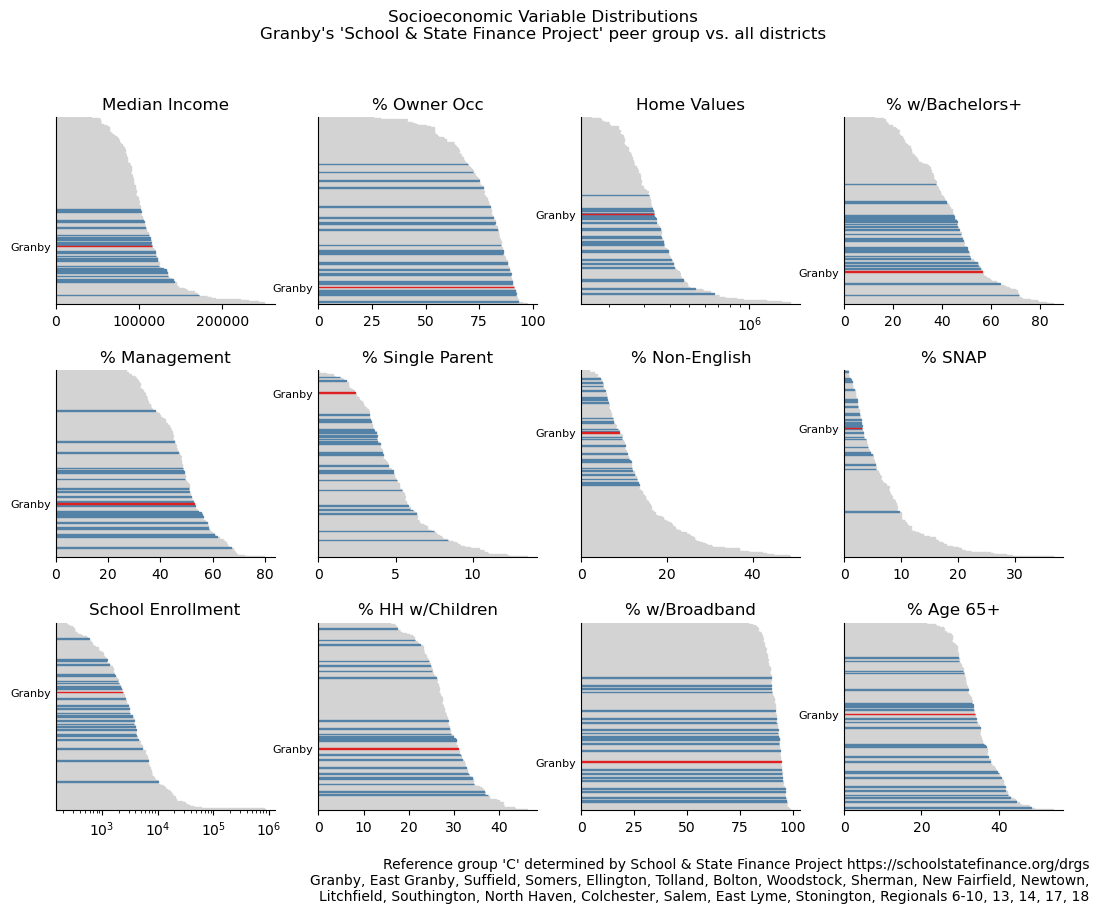

In [65]:
with warnings.catch_warnings(action="ignore"):
    
    fig, axs = plt.subplots(3,4, figsize=(13,9), gridspec_kw={'hspace': 0.35})
    
    for i, demovar in enumerate(mylabels.keys()):
    
        ax = axs.flat[i]
        
        #fig, ax = plt.subplots(1,1,figsize=(6,5))
        sns.barplot(df_original.sort_values(by=demovar), y='Geography', x=demovar, hue='finproj',
                    estimator='mean', orient='h', ax=ax, legend=False, edgecolor=None,
                    palette=['lightgray', 'steelblue', 'red'], gap=0.2)
        
        for patch in ax.patches:
            # Get the current face color of the patch
            face_color = patch.get_facecolor()
            # Set the edgecolor to the same color
            patch.set_edgecolor(face_color)
        
        ax.set_title(f"{mylabels[demovar]}")
        ax.set_ylabel("")
        ax.set_xlabel("")
        g = ax.get_yticklabels()
        ax.set_yticklabels([only_granby(x) for x in g])
        ax.tick_params(axis='y', which='both', length=0, labelsize=8)
    
        xlow, xhigh = ax.get_xlim()
        if xhigh > 500000:
            ax.set_xscale('log')
            
        sns.despine()
    
    fig.suptitle("Socioeconomic Variable Distributions\nGranby's 'School & State Finance Project' peer group vs. all districts", y=1)
   
    drg1 = "Granby, East Granby, Suffield, Somers, Ellington, Tolland, Bolton, Woodstock, Sherman, New Fairfield, Newtown,\n"
    drg2 = "Litchfield, Southington, North Haven, Colchester, Salem, East Lyme, Stonington, Regionals 6-10, 13, 14, 17, 18"
    
    fig.text(.92, 0.01, "Reference group 'C' determined by School & State Finance Project https://schoolstatefinance.org/drgs\n" + drg1 + drg2,
             fontsize=10, ha='right')

    
    plt.savefig("./charts/benchmarking/benchmark_state_school_finance.png", dpi=200, metadata=png_metadata)
    plt.show()

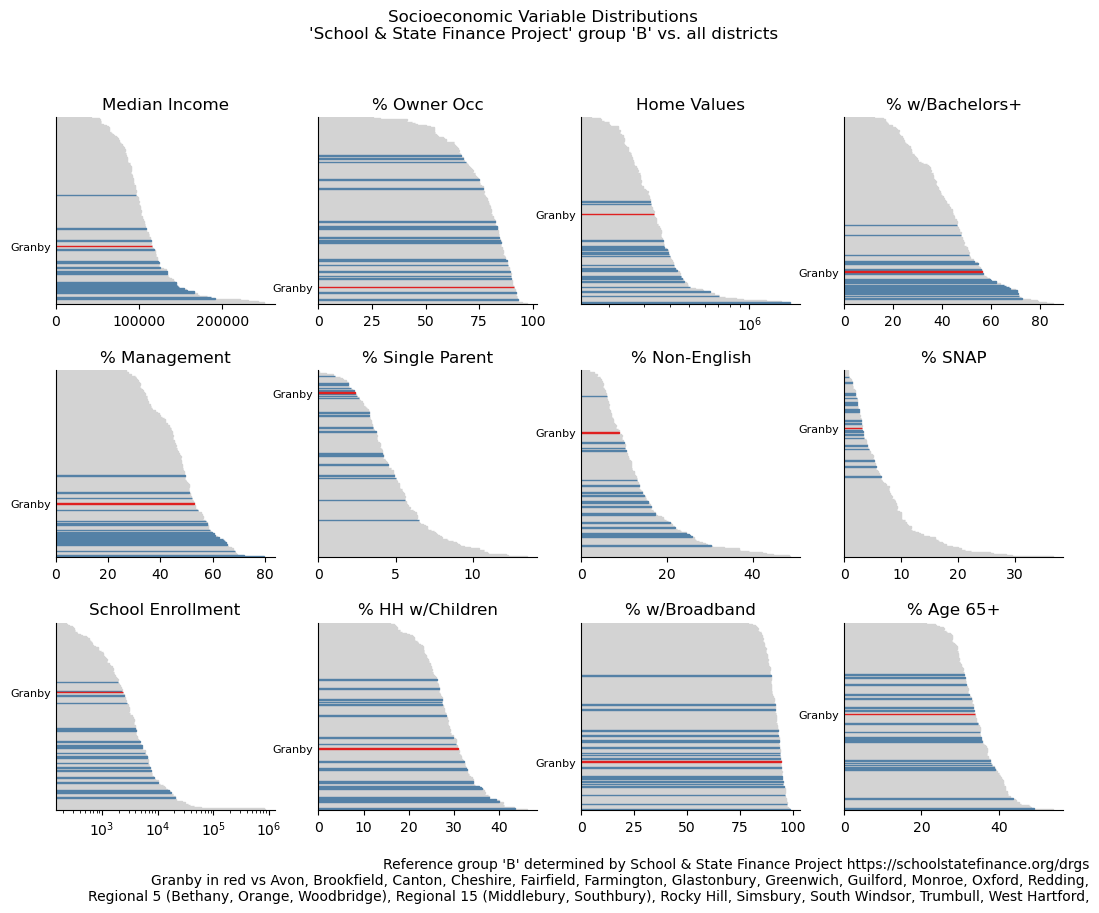

In [66]:
with warnings.catch_warnings(action="ignore"):
    
    fig, axs = plt.subplots(3,4, figsize=(13,9), gridspec_kw={'hspace': 0.35})
    
    for i, demovar in enumerate(mylabels.keys()):
    
        ax = axs.flat[i]
        
        #fig, ax = plt.subplots(1,1,figsize=(6,5))
        sns.barplot(df_original.sort_values(by=demovar), y='Geography', x=demovar, hue='finprojB',
                    estimator='mean', orient='h', ax=ax, legend=False, edgecolor=None,
                    palette=['lightgray', 'steelblue', 'red'], gap=0.2)
        
        for patch in ax.patches:
            # Get the current face color of the patch
            face_color = patch.get_facecolor()
            # Set the edgecolor to the same color
            patch.set_edgecolor(face_color)
        
        ax.set_title(f"{mylabels[demovar]}")
        ax.set_ylabel("")
        ax.set_xlabel("")
        g = ax.get_yticklabels()
        ax.set_yticklabels([only_granby(x) for x in g])
        ax.tick_params(axis='y', which='both', length=0, labelsize=8)
    
        xlow, xhigh = ax.get_xlim()
        if xhigh > 500000:
            ax.set_xscale('log')
            
        sns.despine()
    
    fig.suptitle("Socioeconomic Variable Distributions\n'School & State Finance Project' group 'B' vs. all districts", y=1)
   
    drg1 = "Granby in red vs Avon, Brookfield, Canton, Cheshire, Fairfield, Farmington, Glastonbury, Greenwich, Guilford, Monroe, Oxford, Redding,\n"
    drg2 = "Regional 5 (Bethany, Orange, Woodbridge), Regional 15 (Middlebury, Southbury), Rocky Hill, Simsbury, South Windsor, Trumbull, West Hartford,"
    
    fig.text(.92, 0.01, "Reference group 'B' determined by School & State Finance Project https://schoolstatefinance.org/drgs\n" + drg1 + drg2,
             fontsize=10, ha='right')

    
    plt.savefig("./charts/benchmarking/benchmark_state_school_finance_b.png", dpi=200, metadata=png_metadata)
    plt.show()

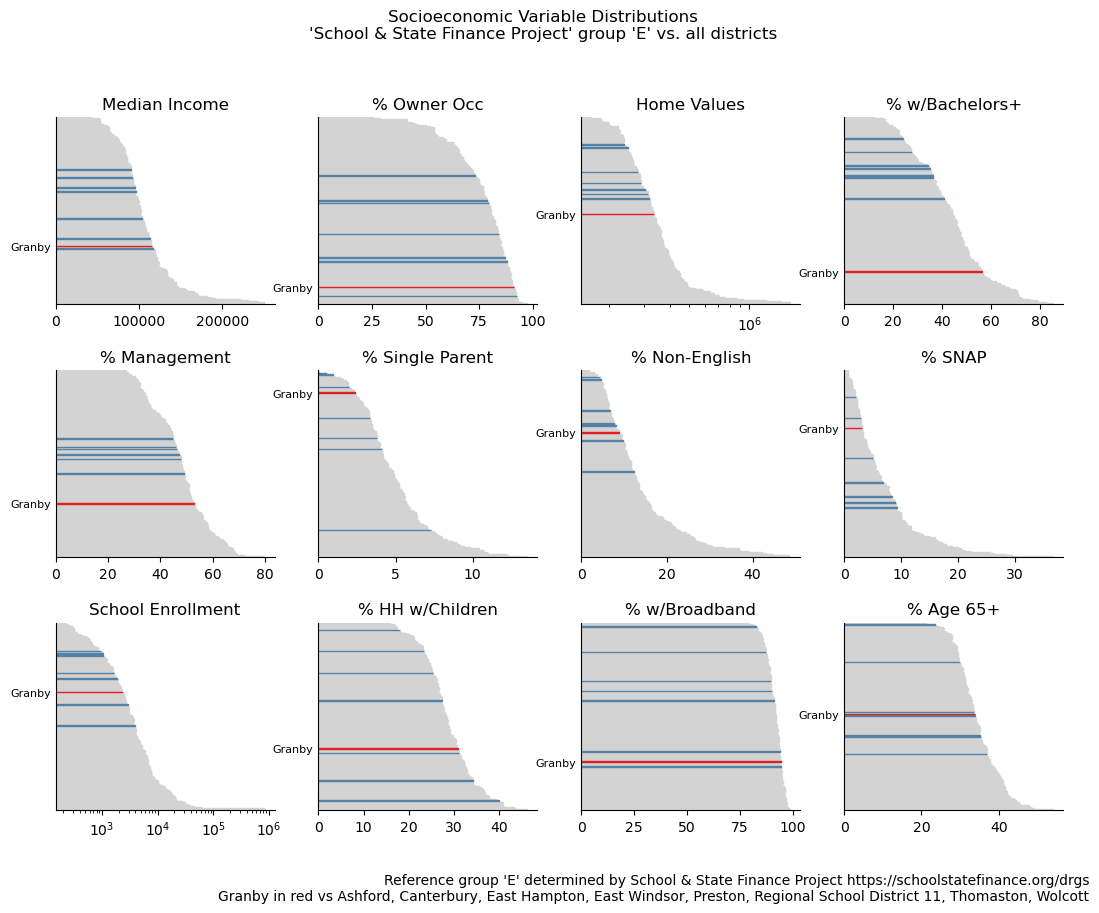

In [67]:
with warnings.catch_warnings(action="ignore"):
    
    fig, axs = plt.subplots(3,4, figsize=(13,9), gridspec_kw={'hspace': 0.35})
    
    for i, demovar in enumerate(mylabels.keys()):
    
        ax = axs.flat[i]
        
        #fig, ax = plt.subplots(1,1,figsize=(6,5))
        sns.barplot(df_original.sort_values(by=demovar), y='Geography', x=demovar, hue='finprojE',
                    estimator='mean', orient='h', ax=ax, legend=False, edgecolor=None,
                    palette=['lightgray', 'steelblue', 'red'], gap=0.2)
        
        for patch in ax.patches:
            # Get the current face color of the patch
            face_color = patch.get_facecolor()
            # Set the edgecolor to the same color
            patch.set_edgecolor(face_color)
        
        ax.set_title(f"{mylabels[demovar]}")
        ax.set_ylabel("")
        ax.set_xlabel("")
        g = ax.get_yticklabels()
        ax.set_yticklabels([only_granby(x) for x in g])
        ax.tick_params(axis='y', which='both', length=0, labelsize=8)
    
        xlow, xhigh = ax.get_xlim()
        if xhigh > 500000:
            ax.set_xscale('log')
            
        sns.despine()

    fig.suptitle("Socioeconomic Variable Distributions\n'School & State Finance Project' group 'E' vs. all districts", y=1)
   
    drg1 = "Granby in red vs Ashford, Canterbury, East Hampton, East Windsor, Preston, Regional School District 11, Thomaston, Wolcott"
    
    fig.text(.92, 0.01, "Reference group 'E' determined by School & State Finance Project https://schoolstatefinance.org/drgs\n" + drg1,
             fontsize=10, ha='right')

    
    plt.savefig("./charts/benchmarking/benchmark_state_school_finance_e.png", dpi=200, metadata=png_metadata)
    plt.show()

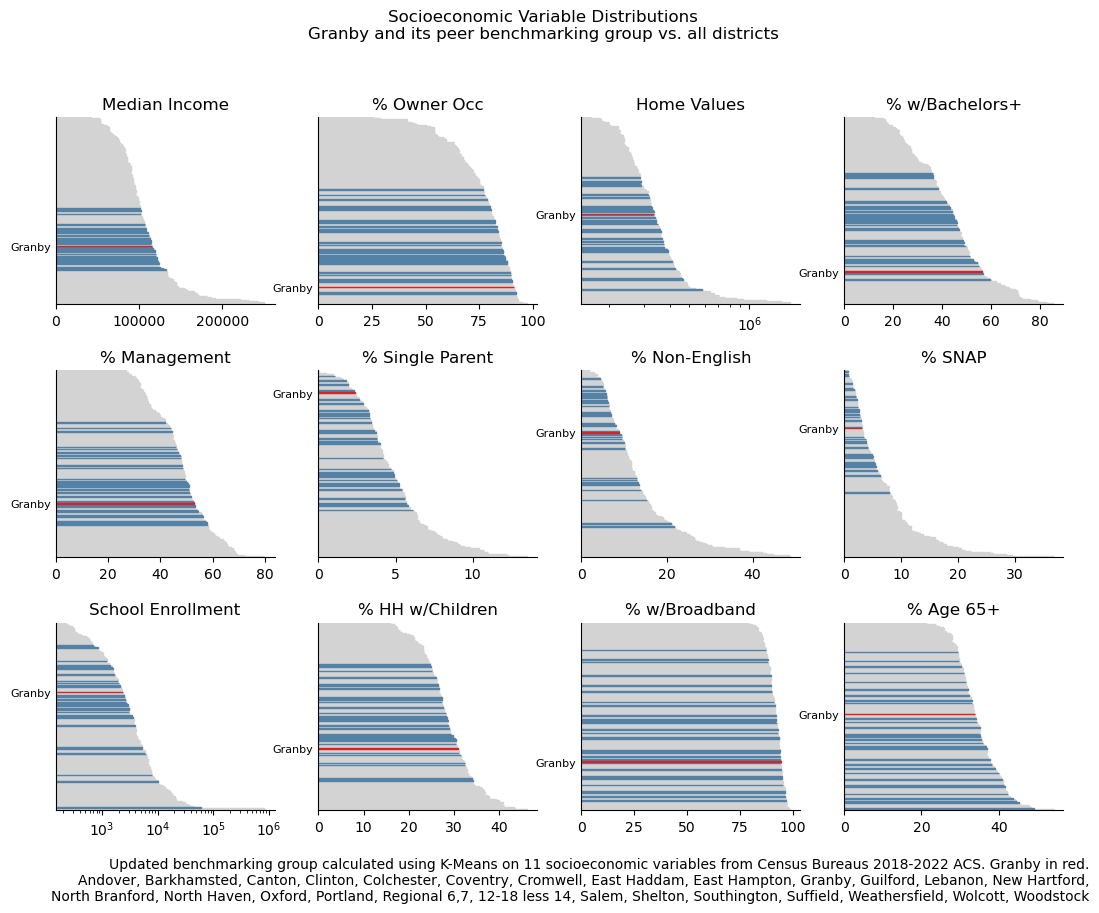

In [68]:
with warnings.catch_warnings(action="ignore"):

    fig, axs = plt.subplots(3,4, figsize=(13,9), gridspec_kw={'hspace': 0.35})
    
    for i, demovar in enumerate(mylabels.keys()):
    
        ax = axs.flat[i]
        
        #fig, ax = plt.subplots(1,1,figsize=(6,5))
        sns.barplot(df_original.sort_values(by=demovar), y='Geography', x=demovar, hue='peer',
                    estimator='mean', orient='h', ax=ax, legend=False, edgecolor=None,
                    palette=['lightgray', 'steelblue', 'red'], gap=0.2)
        
        for patch in ax.patches:
            # Get the current face color of the patch
            face_color = patch.get_facecolor()
            # Set the edgecolor to the same color
            patch.set_edgecolor(face_color)
        
        ax.set_title(f"{mylabels[demovar]}")
        ax.set_ylabel("")
        ax.set_xlabel("")
        g = ax.get_yticklabels()
        ax.set_yticklabels([only_granby(x) for x in g])
        ax.tick_params(axis='y', which='both', length=0, labelsize=8)
    
        xlow, xhigh = ax.get_xlim()
        if xhigh > 500000:
            ax.set_xscale('log')
            
        sns.despine()
    
    fig.suptitle("Socioeconomic Variable Distributions\nGranby and its peer benchmarking group vs. all districts", y=1)

    grp6a = "Andover, Barkhamsted, Canton, Clinton, Colchester, Coventry, Cromwell, East Haddam, East Hampton, Granby, Guilford, Lebanon, New Hartford,\n"
    grp6b = "North Branford, North Haven, Oxford, Portland, Regional 6,7, 12-18 less 14, "
    grp6c = "Salem, Shelton, Southington, Suffield, Weathersfield, Wolcott, Woodstock"
    grp6 = grp6a + grp6b + grp6c
    fig.text(.92, 0.01, "Updated benchmarking group calculated using K-Means on 11 socioeconomic variables from Census Bureaus 2018-2022 ACS. Granby in red.\n" + grp6,
             fontsize=10, ha='right')

    plt.savefig("./charts/benchmarking/benchmark_peers.png", dpi=200, metadata=png_metadata)
    plt.show()

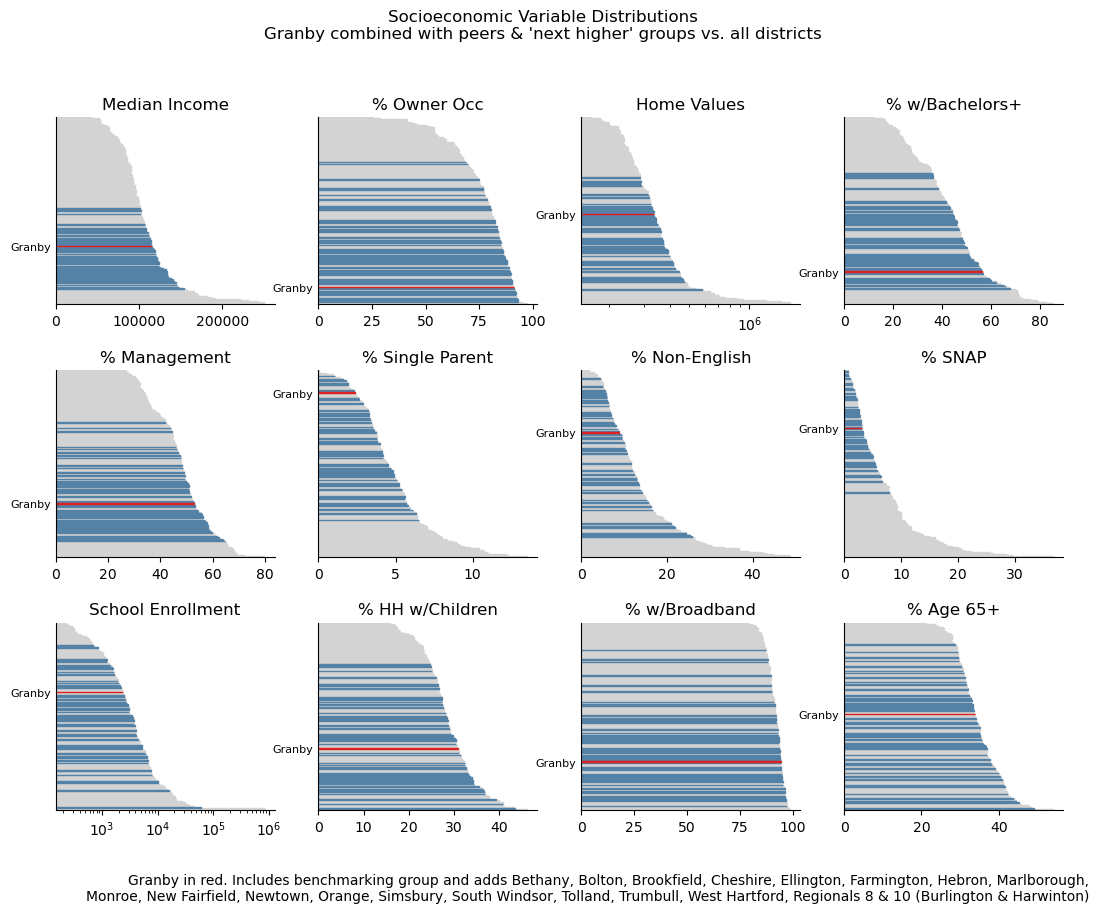

In [69]:
with warnings.catch_warnings(action="ignore"):
    
    fig, axs = plt.subplots(3,4, figsize=(13,9), gridspec_kw={'hspace': 0.35})
    
    for i, demovar in enumerate(mylabels.keys()):
    
        ax = axs.flat[i]
        
        #fig, ax = plt.subplots(1,1,figsize=(6,5))
        sns.barplot(df_original.sort_values(by=demovar), y='Geography', x=demovar, hue='peerplus',
                    estimator='mean', orient='h', ax=ax, legend=False, edgecolor=None,
                    palette=['lightgray', 'steelblue', 'red'], gap=0.2)
        
        for patch in ax.patches:
            # Get the current face color of the patch
            face_color = patch.get_facecolor()
            # Set the edgecolor to the same color
            patch.set_edgecolor(face_color)
        
        ax.set_title(f"{mylabels[demovar]}")
        ax.set_ylabel("")
        ax.set_xlabel("")
        g = ax.get_yticklabels()
        ax.set_yticklabels([only_granby(x) for x in g])
        ax.tick_params(axis='y', which='both', length=0, labelsize=8)
    
        xlow, xhigh = ax.get_xlim()
        if xhigh > 500000:
            ax.set_xscale('log')
            
        sns.despine()

    fig.suptitle("Socioeconomic Variable Distributions\nGranby combined with peers & 'next higher' groups vs. all districts", y=1)

    grp0 = "Monroe, New Fairfield, Newtown, Orange, Simsbury, South Windsor, Tolland, Trumbull, West Hartford, Regionals 8 & 10 (Burlington & Harwinton)"
    fig.text(.92, 0.01, "Granby in red. Includes benchmarking group and adds Bethany, Bolton, Brookfield, Cheshire, Ellington, Farmington, Hebron, Marlborough,\n" + grp0
             , fontsize=10, ha='right')
    
    plt.savefig("./charts/benchmarking/benchmark_peersplus.png", dpi=200, metadata=png_metadata)
    plt.show()


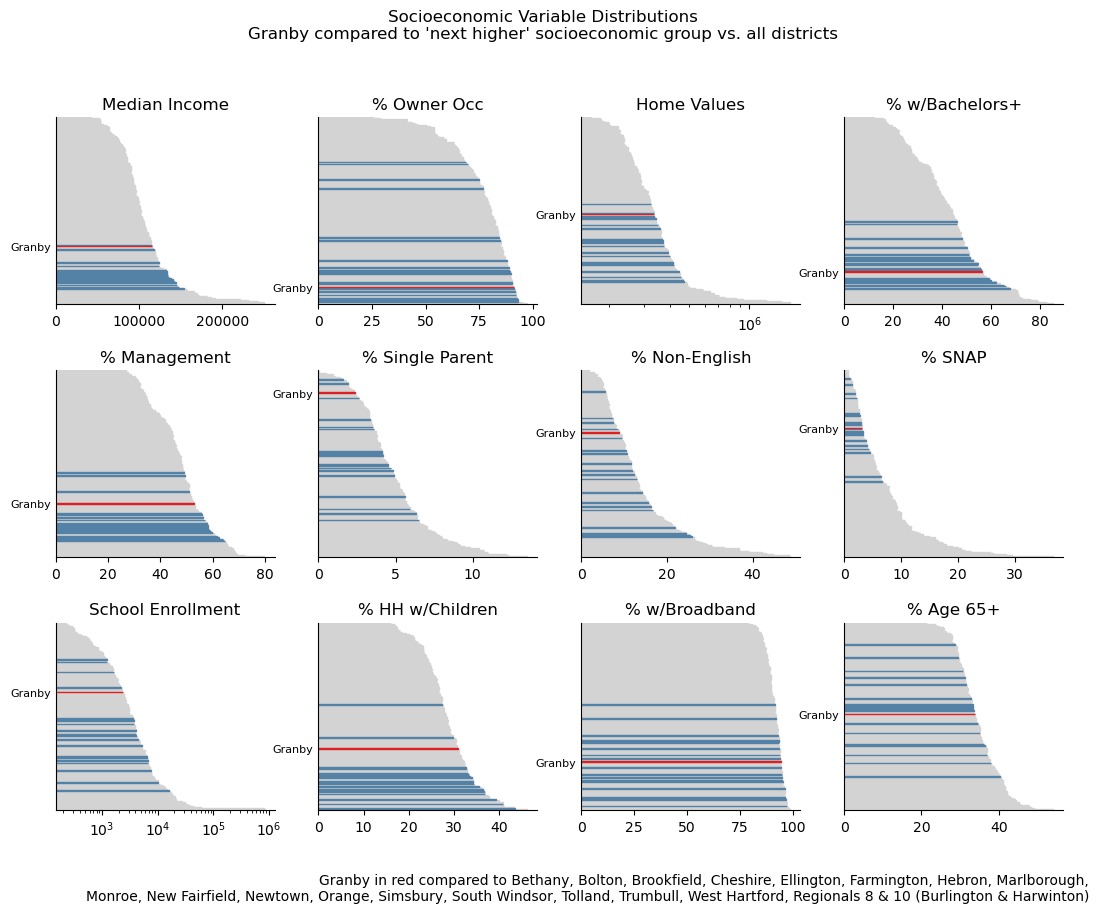

In [70]:
with warnings.catch_warnings(action="ignore"):
    
    fig, axs = plt.subplots(3,4, figsize=(13,9), gridspec_kw={'hspace': 0.35})
    
    for i, demovar in enumerate(mylabels.keys()):
    
        ax = axs.flat[i]
        
        #fig, ax = plt.subplots(1,1,figsize=(6,5))
        sns.barplot(df_original.sort_values(by=demovar), y='Geography', x=demovar, hue='betters',
                    estimator='mean', orient='h', ax=ax, legend=False, edgecolor=None,
                    palette=['lightgray', 'steelblue', 'red'], gap=0.2)
        
        for patch in ax.patches:
            # Get the current face color of the patch
            face_color = patch.get_facecolor()
            # Set the edgecolor to the same color
            patch.set_edgecolor(face_color)
        
        ax.set_title(f"{mylabels[demovar]}")
        ax.set_ylabel("")
        ax.set_xlabel("")
        g = ax.get_yticklabels()
        ax.set_yticklabels([only_granby(x) for x in g])
        ax.tick_params(axis='y', which='both', length=0, labelsize=8)
    
        xlow, xhigh = ax.get_xlim()
        if xhigh > 500000:
            ax.set_xscale('log')
            
        sns.despine()

    fig.suptitle("Socioeconomic Variable Distributions\nGranby compared to 'next higher' socioeconomic group vs. all districts", y=1)
    grp0 = "Monroe, New Fairfield, Newtown, Orange, Simsbury, South Windsor, Tolland, Trumbull, West Hartford, Regionals 8 & 10 (Burlington & Harwinton)"
    fig.text(.92, 0.01, "Granby in red compared to Bethany, Bolton, Brookfield, Cheshire, Ellington, Farmington, Hebron, Marlborough,\n" + grp0,
             fontsize=10, ha='right')
    
    plt.savefig("./charts/benchmarking/benchmark_betters.png", dpi=200, metadata=png_metadata)
    plt.show()


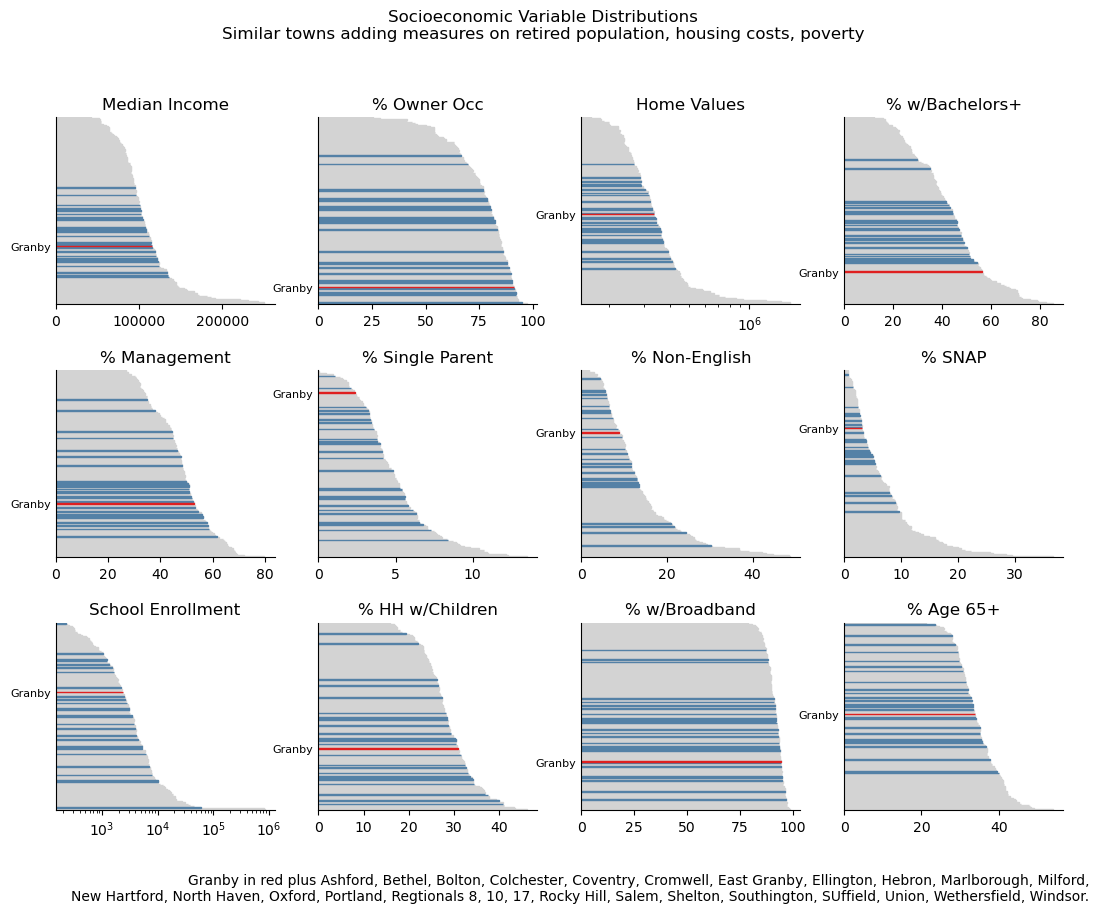

In [71]:
with warnings.catch_warnings(action="ignore"):
    
    fig, axs = plt.subplots(3,4, figsize=(13,9), gridspec_kw={'hspace': 0.35})
    
    for i, demovar in enumerate(mylabels.keys()):
    
        ax = axs.flat[i]
        
        #fig, ax = plt.subplots(1,1,figsize=(6,5))
        sns.barplot(df_original.sort_values(by=demovar), y='Geography', x=demovar, hue='affordable',
                    estimator='mean', orient='h', ax=ax, legend=False, edgecolor=None,
                    palette=['lightgray', 'steelblue', 'red'], gap=0.2)
        
        for patch in ax.patches:
            # Get the current face color of the patch
            face_color = patch.get_facecolor()
            # Set the edgecolor to the same color
            patch.set_edgecolor(face_color)
        
        ax.set_title(f"{mylabels[demovar]}")
        ax.set_ylabel("")
        ax.set_xlabel("")
        g = ax.get_yticklabels()
        ax.set_yticklabels([only_granby(x) for x in g])
        ax.tick_params(axis='y', which='both', length=0, labelsize=8)
    
        xlow, xhigh = ax.get_xlim()
        if xhigh > 500000:
            ax.set_xscale('log')
            
        sns.despine()

    fig.suptitle("Socioeconomic Variable Distributions\nSimilar towns adding measures on retired population, housing costs, poverty", y=1)

    aff1 = "Granby in red plus Ashford, Bethel, Bolton, Colchester, Coventry, Cromwell, East Granby, Ellington, Hebron, Marlborough, Milford,\n"
    aff2 = "New Hartford, North Haven, Oxford, Portland, Regtionals 8, 10, 17, Rocky Hill, Salem, Shelton, Southington, SUffield, Union, Wethersfield, Windsor."
    fig.text(.92, 0.01, aff1 + aff2, fontsize=10, ha='right')

    plt.savefig("./charts/benchmarking/benchmark_affordable.png", dpi=200, metadata=png_metadata)
    plt.show()


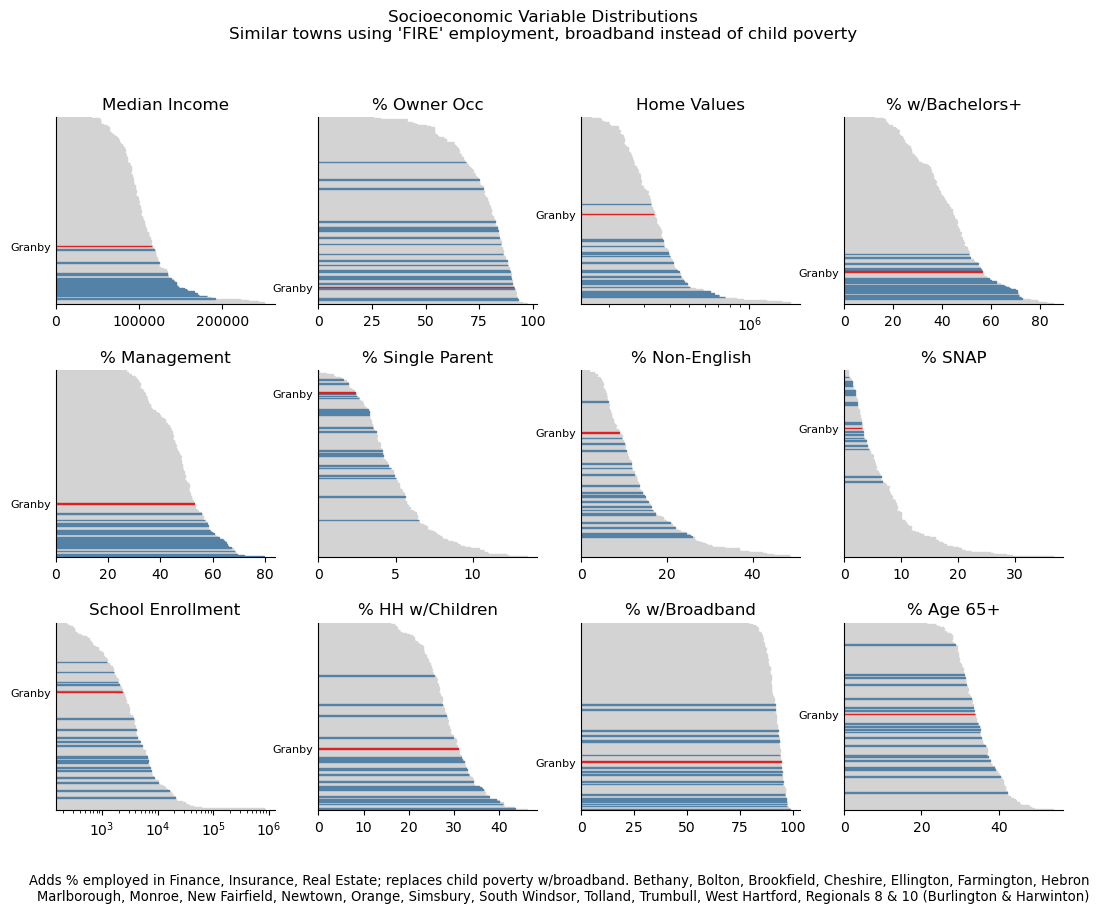

In [72]:
with warnings.catch_warnings(action="ignore"):
    
    fig, axs = plt.subplots(3,4, figsize=(13,9), gridspec_kw={'hspace': 0.35})
    
    for i, demovar in enumerate(mylabels.keys()):
    
        ax = axs.flat[i]
        
        #fig, ax = plt.subplots(1,1,figsize=(6,5))
        sns.barplot(df_original.sort_values(by=demovar), y='Geography', x=demovar, hue='augmented',
                    estimator='mean', orient='h', ax=ax, legend=False, edgecolor=None,
                    palette=['lightgray', 'steelblue', 'red'], gap=0.2)
        
        for patch in ax.patches:
            # Get the current face color of the patch
            face_color = patch.get_facecolor()
            # Set the edgecolor to the same color
            patch.set_edgecolor(face_color)
        
        ax.set_title(f"{mylabels[demovar]}")
        ax.set_ylabel("")
        ax.set_xlabel("")
        g = ax.get_yticklabels()
        ax.set_yticklabels([only_granby(x) for x in g])
        ax.tick_params(axis='y', which='both', length=0, labelsize=8)
    
        xlow, xhigh = ax.get_xlim()
        if xhigh > 500000:
            ax.set_xscale('log')
            
        sns.despine()

    fig.suptitle("Socioeconomic Variable Distributions\nSimilar towns using 'FIRE' employment, broadband instead of child poverty", y=1)
    
    grp0 = "Marlborough, Monroe, New Fairfield, Newtown, Orange, Simsbury, South Windsor, Tolland, Trumbull, West Hartford, Regionals 8 & 10 (Burlington & Harwinton)"
    fig.text(.92, 0.01, "Adds % employed in Finance, Insurance, Real Estate; replaces child poverty w/broadband. Bethany, Bolton, Brookfield, Cheshire, Ellington, Farmington, Hebron\n" + grp0,
             fontsize=9.5, ha='right')

    plt.savefig("./charts/benchmarking/benchmark_firebroadband.png", dpi=200, metadata=png_metadata)
    plt.show()


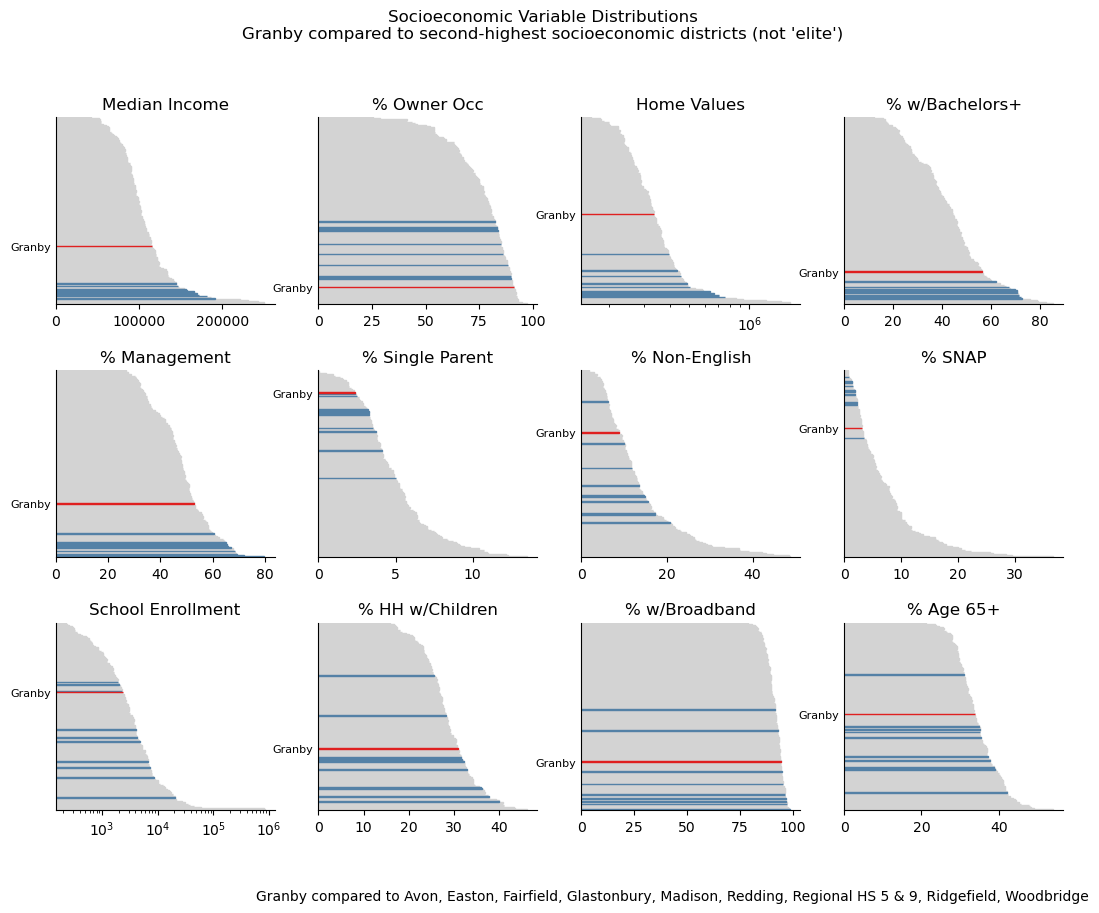

In [73]:
with warnings.catch_warnings(action="ignore"):

    fig, axs = plt.subplots(3,4, figsize=(13,9), gridspec_kw={'hspace': 0.35})
    
    for i, demovar in enumerate(mylabels.keys()):
    
        ax = axs.flat[i]
        
        #fig, ax = plt.subplots(1,1,figsize=(6,5))
        sns.barplot(df_original.sort_values(by=demovar), y='Geography', x=demovar, hue='aspirational',
                    estimator='mean', orient='h', ax=ax, legend=False, edgecolor=None,
                    palette=['lightgray', 'steelblue', 'red'], gap=0.2)
        
        for patch in ax.patches:
            # Get the current face color of the patch
            face_color = patch.get_facecolor()
            # Set the edgecolor to the same color
            patch.set_edgecolor(face_color)
        
        ax.set_title(f"{mylabels[demovar]}")
        ax.set_ylabel("")
        ax.set_xlabel("")
        g = ax.get_yticklabels()
        ax.set_yticklabels([only_granby(x) for x in g])
        ax.tick_params(axis='y', which='both', length=0, labelsize=8)
    
        xlow, xhigh = ax.get_xlim()
        if xhigh > 500000:
            ax.set_xscale('log')
            
        sns.despine()

    fig.suptitle("Socioeconomic Variable Distributions\nGranby compared to second-highest socioeconomic districts (not 'elite')", y=1)
    fig.text(.92, 0.01, "Granby compared to Avon, Easton, Fairfield, Glastonbury, Madison, Redding, Regional HS 5 & 9, Ridgefield, Woodbridge",
             fontsize=10, ha='right')

    plt.savefig("./charts/benchmarking/benchmark_aspirational.png", dpi=200, metadata=png_metadata)
    plt.show()

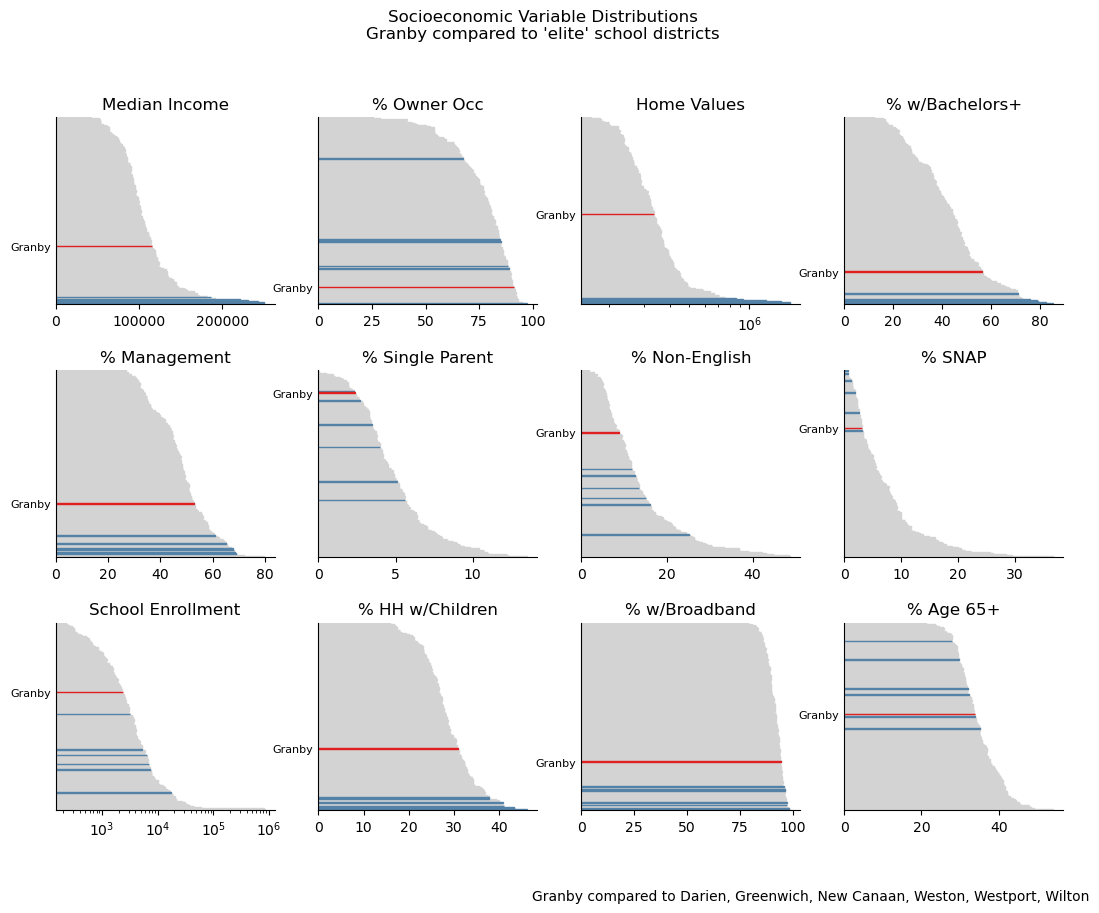

In [74]:
with warnings.catch_warnings(action="ignore"):
    
    fig, axs = plt.subplots(3,4, figsize=(13,9), gridspec_kw={'hspace': 0.35})
    
    for i, demovar in enumerate(mylabels.keys()):
    
        ax = axs.flat[i]
        
        #fig, ax = plt.subplots(1,1,figsize=(6,5))
        sns.barplot(df_original.sort_values(by=demovar), y='Geography', x=demovar, hue='elite',
                    estimator='mean', orient='h', ax=ax, legend=False, edgecolor=None,
                    palette=['lightgray', 'steelblue', 'red'], gap=0.2)
        
        for patch in ax.patches:
            # Get the current face color of the patch
            face_color = patch.get_facecolor()
            # Set the edgecolor to the same color
            patch.set_edgecolor(face_color)
        
        ax.set_title(f"{mylabels[demovar]}")
        ax.set_ylabel("")
        ax.set_xlabel("")
        g = ax.get_yticklabels()
        ax.set_yticklabels([only_granby(x) for x in g])
        ax.tick_params(axis='y', which='both', length=0, labelsize=8)
    
        xlow, xhigh = ax.get_xlim()
        if xhigh > 500000:
            ax.set_xscale('log')
            
        sns.despine()
    
    fig.suptitle("Socioeconomic Variable Distributions\nGranby compared to 'elite' school districts", y=1)
    fig.text(.92, 0.01, "Granby compared to Darien, Greenwich, New Canaan, Weston, Westport, Wilton", fontsize=10, ha='right')
    
    plt.savefig("./charts/benchmarking/benchmark_elite.png", dpi=200, metadata=png_metadata)
    plt.show()


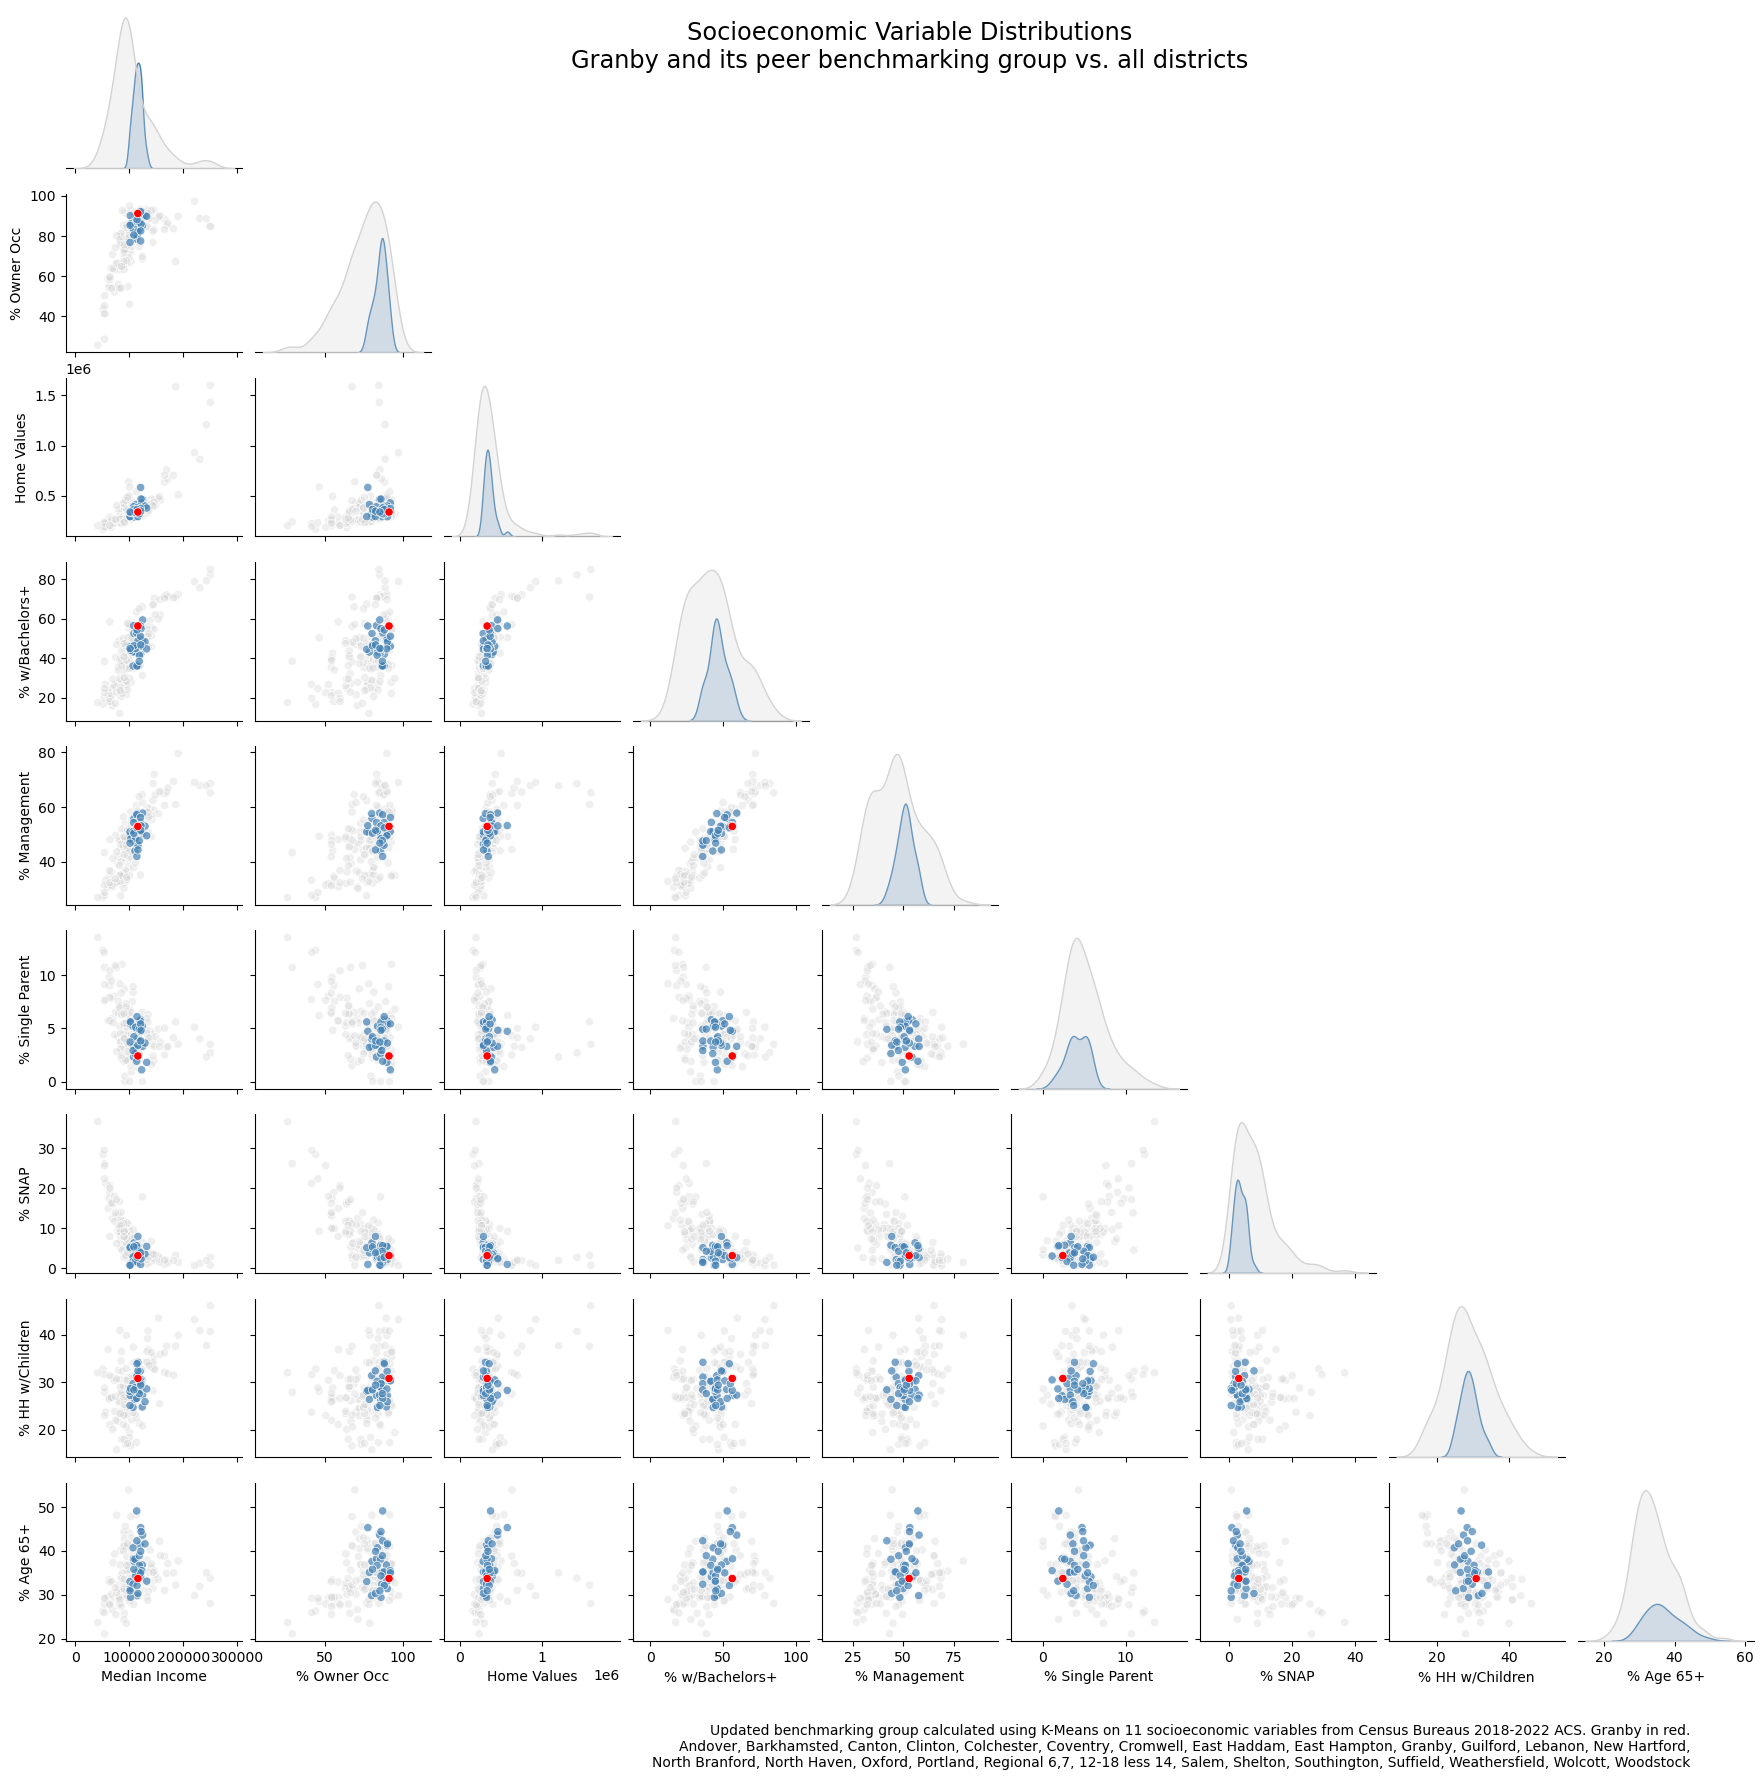

In [75]:
huecols = [(0.827, 0.827, 0.827, .35),
           (0.27450980392156865, 0.5098039215686274, 0.7058823529411765, .7),
           (1.0, 0.0, 0.0, 1.0)]

sns.set_palette(huecols)

with warnings.catch_warnings(action="ignore"):
    g = sns.pairplot(df_original[['peer'] + list(mylabels.keys())].rename(columns=mylabels)\
                     .drop(columns=['School Enrollment', '% w/Broadband', '% Non-English']).sort_values(by='peer'),
                     hue="peer", palette=huecols, height=2, corner=True,)
    g._legend.remove() 
    
    g.fig.suptitle("Socioeconomic Variable Distributions\nGranby and its peer benchmarking group vs. all districts", fontsize='xx-large')

    plt.subplots_adjust(bottom=0.08)
    grp6a = "Andover, Barkhamsted, Canton, Clinton, Colchester, Coventry, Cromwell, East Haddam, East Hampton, Granby, Guilford, Lebanon, New Hartford,\n"
    grp6b = "North Branford, North Haven, Oxford, Portland, Regional 6,7, 12-18 less 14, "
    grp6c = "Salem, Shelton, Southington, Suffield, Weathersfield, Wolcott, Woodstock"
    grp6 = grp6a + grp6b + grp6c
    g.fig.text(.92, 0.01, "Updated benchmarking group calculated using K-Means on 11 socioeconomic variables from Census Bureaus 2018-2022 ACS. Granby in red.\n" + grp6,
            fontsize=10, ha='right')

    plt.savefig("./charts/benchmarking/benchmark_peer_scatter.png", dpi=200, metadata=png_metadata)
    plt.show()

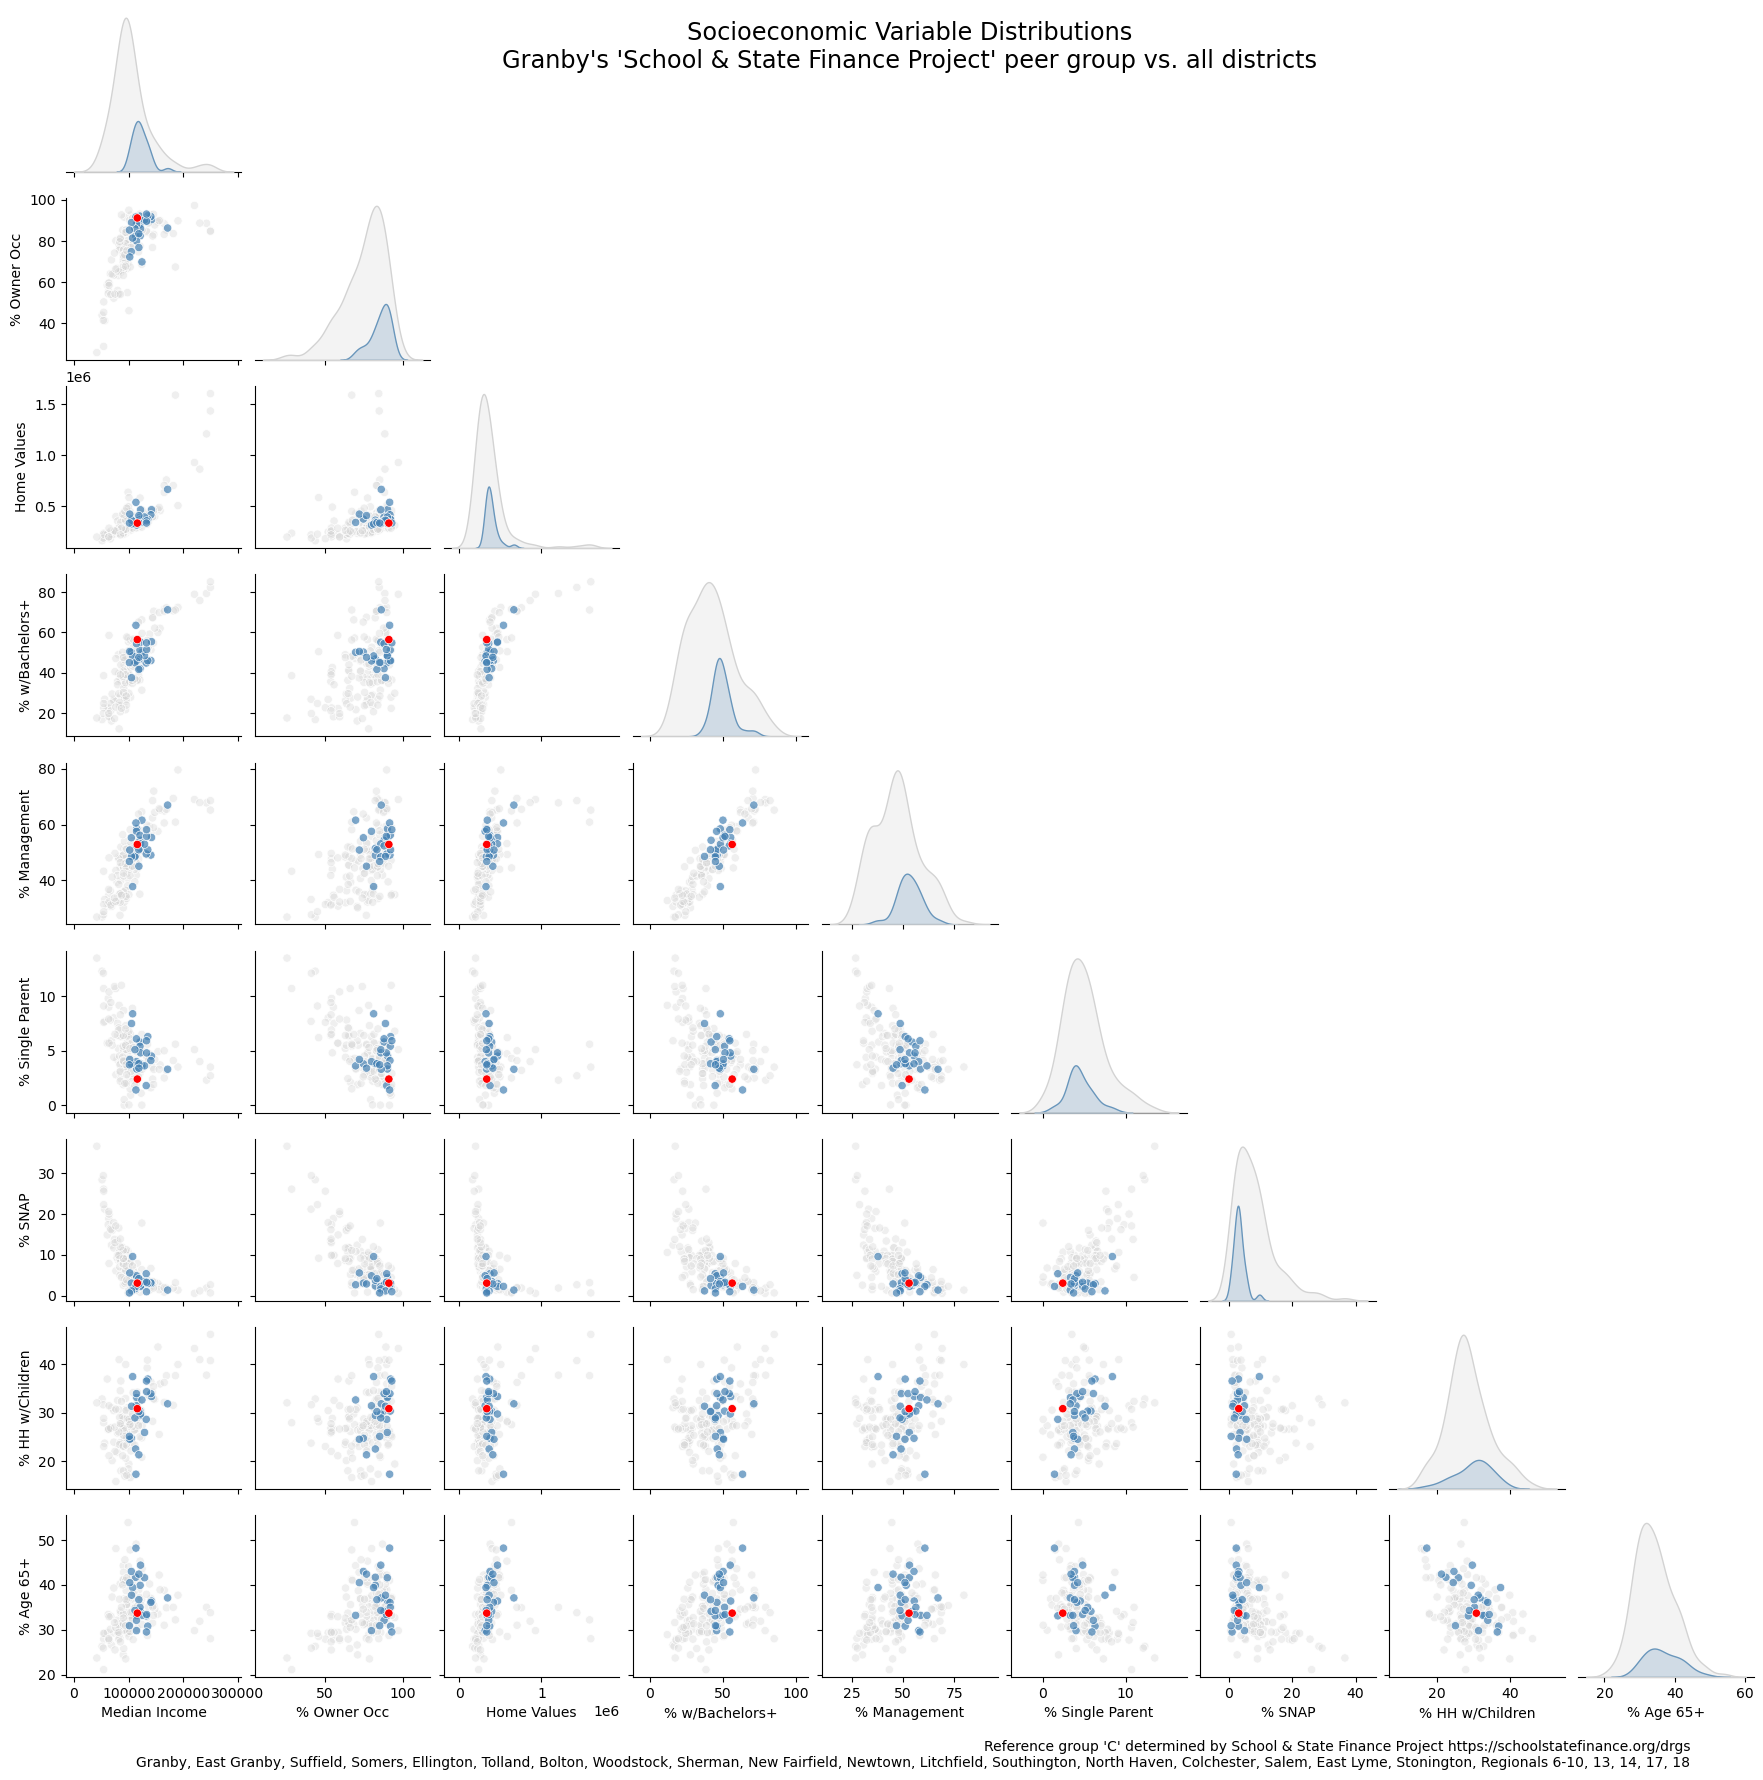

In [76]:
with warnings.catch_warnings(action="ignore"):
    g = sns.pairplot(df_original[['finproj'] + list(mylabels.keys())].rename(columns=mylabels)\
                     .drop(columns=['School Enrollment', '% w/Broadband', '% Non-English']).sort_values(by='finproj'),
                     hue="finproj", 
                     palette=huecols, height=2,
                     corner=True)
    g._legend.remove() 
    g.fig.suptitle("Socioeconomic Variable Distributions\nGranby's 'School & State Finance Project' peer group vs. all districts",fontsize='xx-large')
    
    plt.subplots_adjust(bottom=0.06)
    drg1 = "Granby, East Granby, Suffield, Somers, Ellington, Tolland, Bolton, Woodstock, Sherman, New Fairfield, Newtown, "
    drg2 = "Litchfield, Southington, North Haven, Colchester, Salem, East Lyme, Stonington, Regionals 6-10, 13, 14, 17, 18"
    
    g.fig.text(.92, 0.01, "Reference group 'C' determined by School & State Finance Project https://schoolstatefinance.org/drgs\n" + drg1 + drg2,
             fontsize=10, ha='right')
    
    plt.savefig("./charts/benchmarking/benchmark_state_school_scatter.png", dpi=200, metadata=png_metadata)
    plt.show()

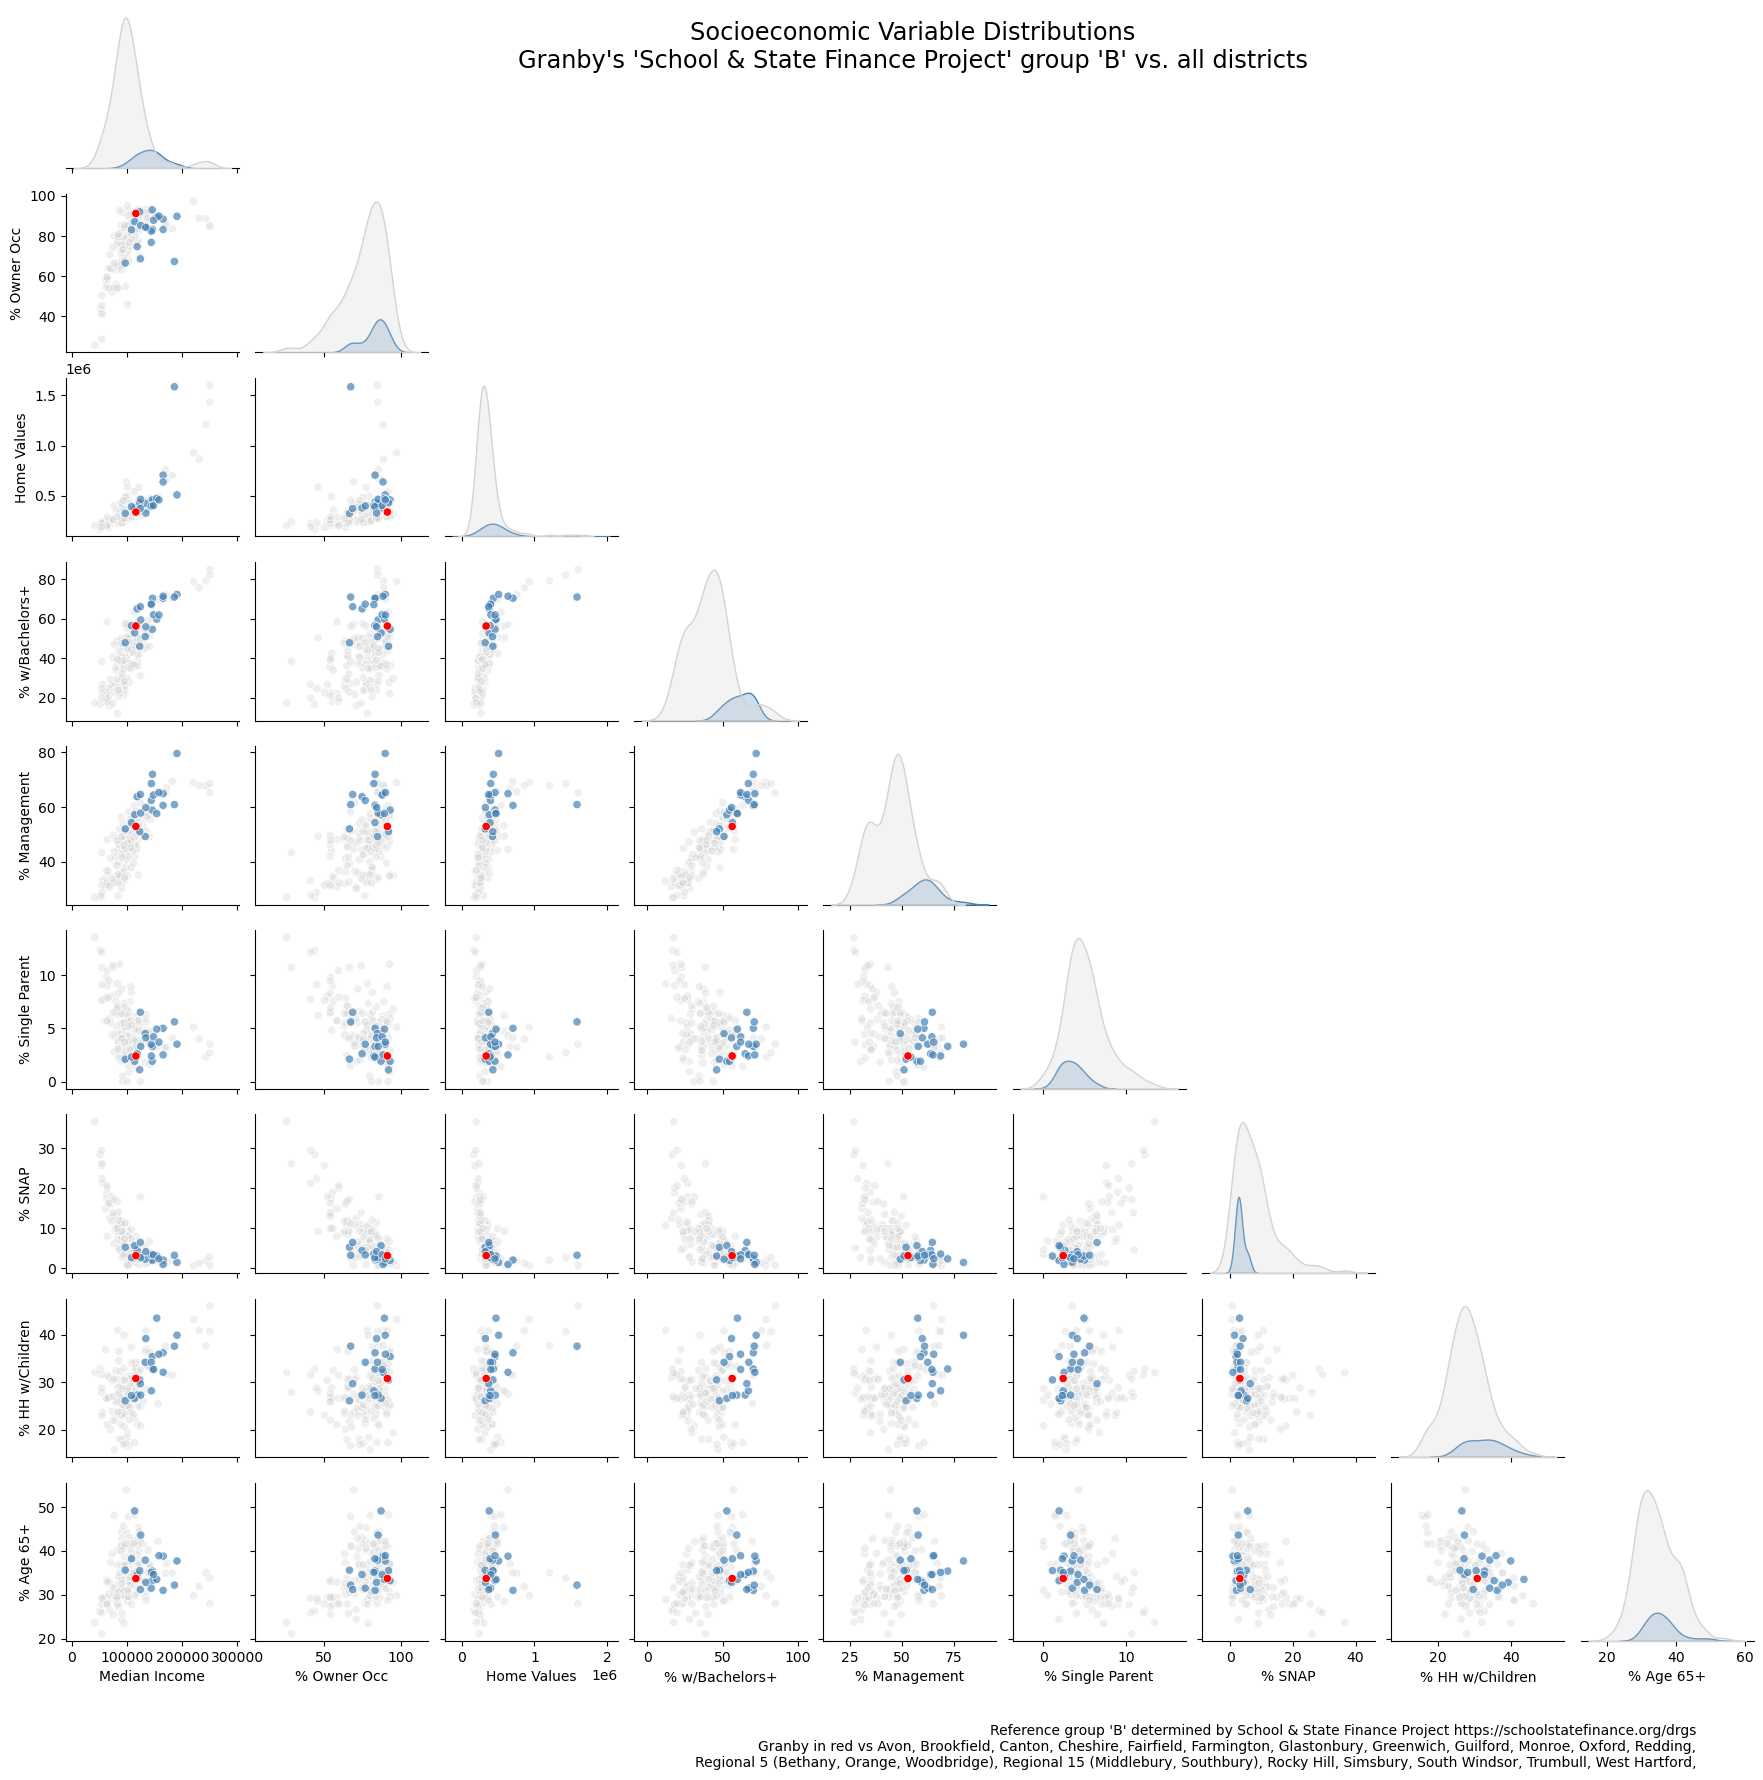

In [77]:
with warnings.catch_warnings(action="ignore"):
    g = sns.pairplot(df_original[['finprojB'] + list(mylabels.keys())].rename(columns=mylabels)\
                     .drop(columns=['School Enrollment', '% w/Broadband', '% Non-English']).sort_values(by='finprojB'),
                     hue="finprojB", 
                     palette=huecols, height=2,
                     corner=True)
    g._legend.remove() 
    g.fig.suptitle("Socioeconomic Variable Distributions\nGranby's 'School & State Finance Project' group 'B' vs. all districts",fontsize='xx-large')
    
    plt.subplots_adjust(bottom=0.08)
    drg1 = "Granby in red vs Avon, Brookfield, Canton, Cheshire, Fairfield, Farmington, Glastonbury, Greenwich, Guilford, Monroe, Oxford, Redding,\n"
    drg2 = "Regional 5 (Bethany, Orange, Woodbridge), Regional 15 (Middlebury, Southbury), Rocky Hill, Simsbury, South Windsor, Trumbull, West Hartford,"
    g.fig.text(.92, 0.01, "Reference group 'B' determined by School & State Finance Project https://schoolstatefinance.org/drgs\n" + drg1 + drg2,
             fontsize=10, ha='right')
    
    plt.savefig("./charts/benchmarking/benchmark_state_school_scatter_b.png", dpi=200, metadata=png_metadata)
    plt.show()

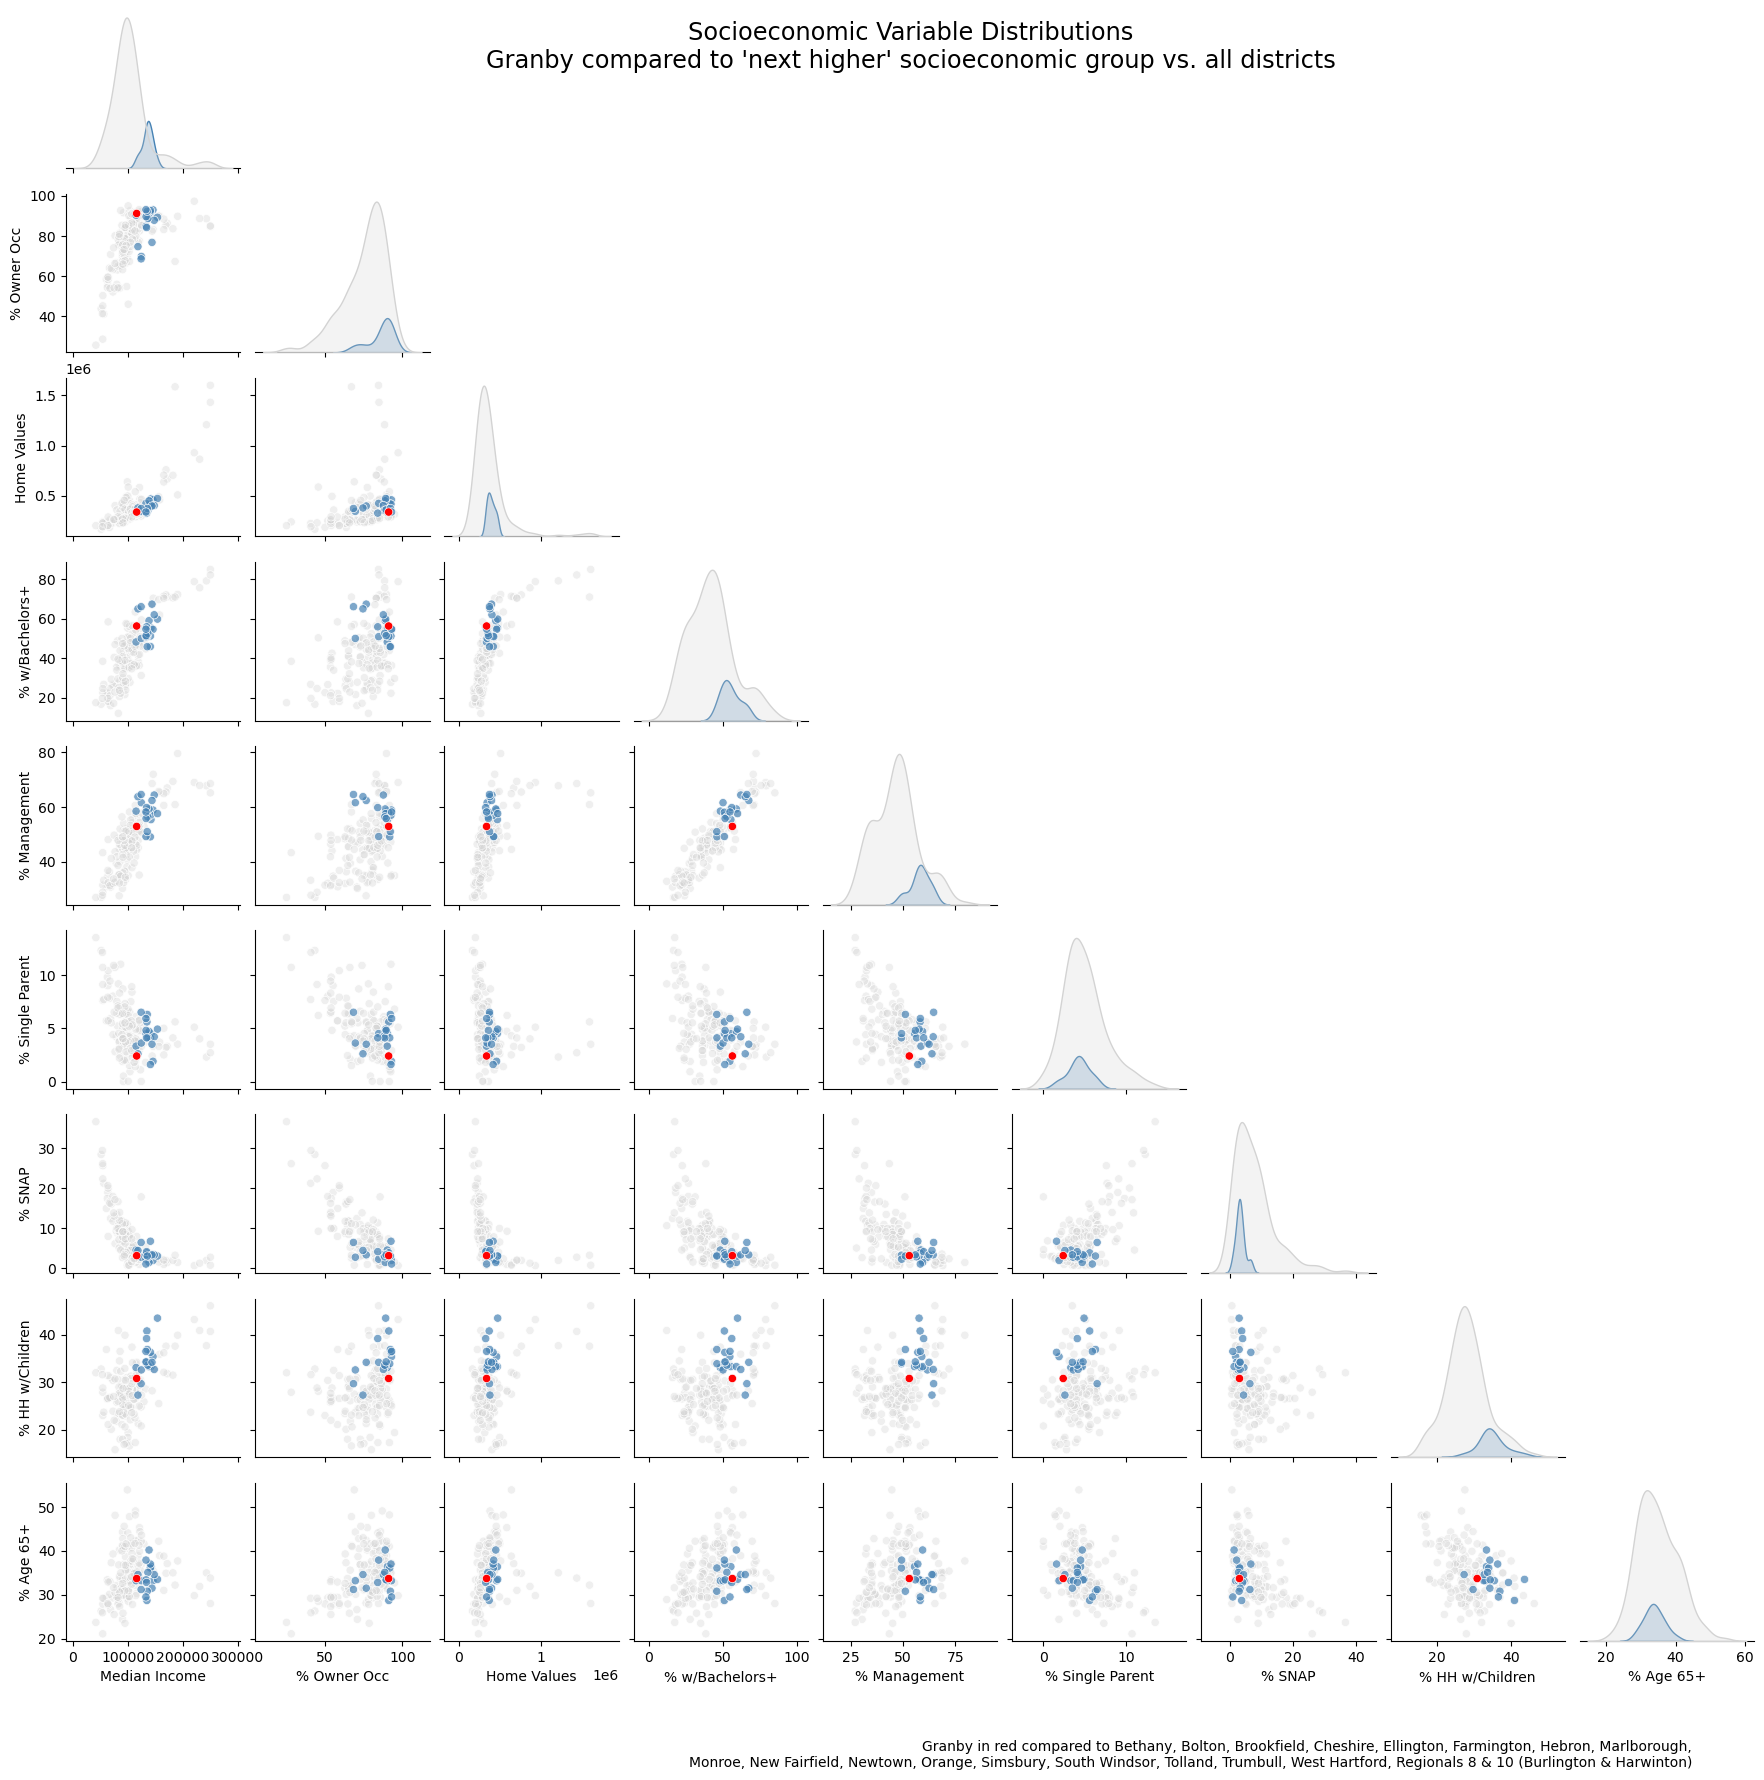

In [78]:
with warnings.catch_warnings(action="ignore"):
    g = sns.pairplot(df_original[['betters'] + list(mylabels.keys())].rename(columns=mylabels)\
                     .drop(columns=['School Enrollment', '% w/Broadband', '% Non-English']).sort_values(by='betters'),
                     hue="betters", 
                     palette=huecols, height=2.,
                     corner=True)
    g._legend.remove()
    g.fig.suptitle("Socioeconomic Variable Distributions\nGranby compared to 'next higher' socioeconomic group vs. all districts", fontsize='xx-large')
    
    plt.subplots_adjust(bottom=0.08)
    grp0 = "Monroe, New Fairfield, Newtown, Orange, Simsbury, South Windsor, Tolland, Trumbull, West Hartford, Regionals 8 & 10 (Burlington & Harwinton)"
    g.fig.text(.92, 0.01, "Granby in red compared to Bethany, Bolton, Brookfield, Cheshire, Ellington, Farmington, Hebron, Marlborough,\n" + grp0,
              fontsize=10, ha='right')

    plt.savefig("./charts/benchmarking/benchmark_betters_scatter.png", dpi=200, metadata=png_metadata)
    plt.show()

In [79]:
df.columns

Index(['GeoId', 'Geography', 'LEAID', 'Year', 'DP02_1est', 'DP02_2pct',
       'DP02_3pct', 'DP02_7pct', 'DP02_11pct', 'DP02_14pct', 'DP02_15pct',
       'DP02_16est', 'DP02_53est', 'DP02_17est', 'DP02_66pct', 'DP02_67pct',
       'DP02_68pct', 'DP02_114pct', 'DP02_153pct', 'DP02_154pct', 'DP02_45pct',
       'DP02_711pct', 'DP03_5pct', 'DP03_7pct', 'DP03_9pct', 'DP03_24pct',
       'DP03_25est', 'DP03_27pct', 'DP03_35pct', 'DP03_39pct', 'DP03_40pct',
       'DP03_49pct', 'DP03_62est', 'DP03_66pct', 'DP03_68pct', 'DP03_72pct',
       'DP03_74pct', 'DP03_97pct', 'DP03_98pct', 'DP03_99pct', 'DP03_119pct',
       'DP03_120pct', 'DP03_525pct', 'DP03_601pct', 'DP03_PRO', 'DP04_3pct',
       'DP04_4est', 'DP04_5est', 'DP04_7pct', 'DP04_14pct', 'DP04_46pct',
       'DP04_47pct', 'DP04_89est', 'DP04_91pct', 'DP04_101est', 'DP04_109est',
       'DP04_134est', 'DP04_878pct', 'DP04_989pct', 'DP04_1412pct',
       'DP04_1234pct', 'DP04_1145pct', 'JSG_PCA30', 'JSG_PCA10', 'JSG_ORIG',
       'JSG_AU

In [80]:
mylabels

{'DP03_62est': 'Median Income',
 'DP04_46pct': '% Owner Occ',
 'DP04_89est': 'Home Values',
 'DP02_68pct': '% w/Bachelors+',
 'DP03_27pct': '% Management',
 'DP02_711pct': '% Single Parent',
 'DP02_114pct': '% Non-English',
 'DP03_74pct': '% SNAP',
 'DP02_53est': 'School Enrollment',
 'DP02_14pct': '% HH w/Children',
 'DP02_154pct': '% w/Broadband',
 'DP02_15pct': '% Age 65+'}

## Store Data

In [81]:
df_original[['District', 'peer', 'augmented', 'aspirational', 'peerplus', 'elite', 'urban', 'pca', 'affordable',
             'finproj', 'finprojB', 'finprojE', 'JSG_ORIG', 'JSG_AUG', 'JSG_AFF', 'JSG_PCA10']
    + list(mylabels.keys())]\
    .rename(columns=mylabels).to_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/new_district_groups.parquet')

## Print Groups

In [82]:
with pd.option_context('display.max_rows', None):
    for g in sorted(df.JSG_ORIG.unique()):
        print(f" ----- Group {g} -----")
        print(df[df.JSG_ORIG == g]['Geography'])
        print("\n")

 ----- Group 0 -----
6               Bethany School District, CT
9                Bolton School District, CT
14           Brookfield School District, CT
20             Cheshire School District, CT
42            Ellington School District, CT
46           Farmington School District, CT
58               Hebron School District, CT
68          Marlborough School District, CT
72               Monroe School District, CT
77        New Fairfield School District, CT
83              Newtown School District, CT
92               Orange School District, CT
106    Regional High School District 08, CT
111         Regional School District 10, CT
131            Simsbury School District, CT
133       South Windsor School District, CT
144             Tolland School District, CT
146            Trumbull School District, CT
154       West Hartford School District, CT
Name: Geography, dtype: object


 ----- Group 1 -----
10            Bozrah School District, CT
21           Chester School District, CT
51     

In [83]:
df_original.rename(columns=mylabels)

,District,peer,augmented,aspirational,peerplus,elite,urban,pca,affordable,finproj,...,DP04_1234pct,DP04_1145pct,Median Income,DP04_101est,DP04_109est,DP04_134est,GeoId,Geography,LEAID,Year
0,Andover School District,1,0,0,1,0,0,0,0,0,...,7.2,34.4,124167.0,2301.0,1088.0,966.0,9500000US0900030,"Andover School District, CT",900030,2018-2022
1,Ansonia School District,0,0,0,0,0,0,0,0,0,...,28.9,35.8,67474.0,2079.0,897.0,1329.0,9700000US0900060,"Ansonia School District, CT",900060,2018-2022
2,Ashford School District,0,0,0,0,0,0,1,1,0,...,10.6,31.7,94778.0,2454.0,879.0,1205.0,9500000US0900090,"Ashford School District, CT",900090,2018-2022
3,Avon School District,0,1,1,0,0,0,0,0,0,...,19.9,21.1,146153.0,3048.0,1364.0,1586.0,9700000US0900120,"Avon School District, CT",900120,2018-2022
4,Barkhamsted School District,1,0,0,1,0,0,1,0,0,...,4.6,20.5,120125.0,2218.0,826.0,1323.0,9500000US0900150,"Barkhamsted School District, CT",900150,2018-2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,Windsor Locks School District,0,0,0,0,0,0,0,0,0,...,19.1,26.2,85570.0,1840.0,791.0,1303.0,9700000US0905250,"Windsor Locks School District, CT",905250,2018-2022
165,Windsor School District,0,0,0,0,0,0,0,1,0,...,16.7,30.6,103521.0,2064.0,927.0,1551.0,9700000US0905220,"Windsor School District, CT",905220,2018-2022
166,Wolcott School District,1,0,0,1,0,0,0,0,0,...,24.0,25.6,113433.0,2265.0,894.0,1486.0,9700000US0905280,"Wolcott School District, CT",905280,2018-2022
167,Woodbridge School District,0,1,1,0,0,0,0,0,0,...,6.7,24.5,190536.0,3584.0,1500.0,1812.0,9500000US0905310,"Woodbridge School District, CT",905310,2018-2022
